# A Framework for Bitcoin Bubble Risk Management

## Libraries upload

In [ ]:
pip install lppls

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 20.7 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
#import time
import numpy as np
from sklearn.preprocessing import MinMaxScaler

## Full dataset upload

In [ ]:
df = pd.read_csv('df.csv')
print(df.head())

In [ ]:
df = df.rename(columns={'Close': 'BCP', 'fear_greed_index': 'FGI'})

df['Date'] = pd.to_datetime(df['Date'])

print(df.head())

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['BCP'])
plt.title('Close Price of df Dataset')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.show()

### Seleziono l'intervallo di interesse: giugno 2022- marzo 2026


In [ ]:
df.tail()

In [ ]:
start_date = pd.to_datetime('2022-06-22')
end_date = pd.to_datetime('2026-03-23')

df_filtered = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)].copy()

print("Filtered DataFrame (df_filtered) from November 2018 to January 2023:")
print(df_filtered.head())
print(df_filtered.tail())

In [ ]:
df_filtered = df_filtered.reset_index(drop=True)
print(df_filtered.head())

In [ ]:
df = df_filtered

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['BCP'])
plt.title('Close Price of df Dataset')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.show()

## LPPLS Bubbles Indicator

In [ ]:
import pandas as pd
df = pd.read_csv('dfA.csv')
print(df.head())
print(df.tail())

         Date           BCP   FGI  log_price  t  lppls_score  lppls_r2_score  \
0  2022-06-22  19987.029297  11.0   9.902839  0          0.0             0.0   
1  2022-06-23  21085.876953  11.0   9.956359  1          0.0             0.0   
2  2022-06-24  21231.656250  11.0   9.963249  2          0.0             0.0   
3  2022-06-25  21502.337891  14.0   9.975917  3          0.0             0.0   
4  2022-06-26  21027.294922  14.0   9.953577  4          0.0             0.0   

   lppls_urgency  lppls_tc_median  lppls_days_to_tc  ...  \
0            0.0              NaN               NaN  ...   
1            0.0              NaN               NaN  ...   
2            0.0              NaN               NaN  ...   
3            0.0              NaN               NaN  ...   
4            0.0              NaN               NaN  ...   

   lppls_score_tc_smooth_smooth  lppls_urgency_smooth_tc_smooth  \
0                           0.0                             0.0   
1                       

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

### Nuova versione solo con R2 e VALID FITS

In [ ]:
import numpy as np
import pandas as pd
from lppls import lppls
from tqdm.notebook import tqdm

# ==============================
# PARAMETERS
# ==============================
MAX_WINDOW_SIZE = 210
MIN_WINDOW_SIZE = 30
WINDOW_STEP = 15

N_FITS = 15          # increased from 5
MAX_SEARCHES = 5

MIN_TC_DAYS = 0
MAX_TC_DAYS = 180

M_MIN, M_MAX = 0.01, 0.99
OMEGA_MIN, OMEGA_MAX = 4.0, 17.0

SMOOTH_WINDOW = 25
TC_SMOOTH_WINDOW = 20
NORM_WINDOW = 365

W_R2 = 0.60
W_URGENCY = 0.40

FIT_WEIGHT_SCALE = 10


# ==============================
# HELPER FUNCTIONS
# ==============================
def lppls_function(t, tc, m, w, a, b, c, phi):
    dt = np.maximum(tc - t, 1e-6)
    return a + b * (dt ** m) + c * (dt ** m) * np.cos(w * np.log(dt) + phi)


def compute_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot if ss_tot > 0 else 0.0


def urgency_exp(days_to_tc, scale=90):
    """
    Smooth urgency transformation.
    High when tc is close, lower when tc is far.
    """
    if pd.isna(days_to_tc):
        return 0.0

    days_to_tc = max(days_to_tc, 0)
    return float(np.exp(-days_to_tc / scale))


# ==============================
# PREPARE DATA
# ==============================
df = df.copy()

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

if 'log_price' not in df.columns:
    df['log_price'] = np.log(df['BCP'])

if 't' not in df.columns:
    df['t'] = np.arange(len(df))

# ==============================
# OUTPUT COLUMNS
# ==============================
output_cols = [
    'lppls_score_raw',
    'lppls_score',
    'lppls_r2_score',
    'lppls_urgency',
    'lppls_fit_weight',
    'lppls_tc_median',
    'lppls_days_to_tc',
    'lppls_valid_fits'
]

for col in output_cols:
    df[col] = np.nan

df['lppls_score_raw'] = 0.0
df['lppls_score'] = 0.0
df['lppls_r2_score'] = 0.0
df['lppls_urgency'] = 0.0
df['lppls_fit_weight'] = 0.0
df['lppls_valid_fits'] = 0


# ==============================
# MAIN LOOP
# ==============================
print("Starting fixed LPPLS score: R² + smoothed urgency + fit-density weighting")

for i in tqdm(range(MAX_WINDOW_SIZE, len(df)), desc="LPPLS fixed score"):

    current_t = df.loc[i, 't']

    tc_list = []
    r2_list = []

    for window_size in range(MIN_WINDOW_SIZE, MAX_WINDOW_SIZE + 1, WINDOW_STEP):

        window = df.iloc[i - window_size:i]

        observations = np.array([
            window['t'].values,
            window['log_price'].values
        ])

        model = lppls.LPPLS(observations=observations)

        for _ in range(N_FITS):

            try:
                fit_result = model.fit(max_searches=MAX_SEARCHES)

                if not isinstance(fit_result, tuple) or len(fit_result) < 7:
                    continue

                tc, m, w, a, b, c, phi = fit_result[:7]

                days_to_tc = tc - current_t

                # ------------------------------
                # Structural filters
                # ------------------------------
                if days_to_tc < MIN_TC_DAYS:
                    continue

                if b >= 0:
                    continue

                if not (M_MIN < m < M_MAX):
                    continue

                if not (OMEGA_MIN < w < OMEGA_MAX):
                    continue

                # ------------------------------
                # R²
                # ------------------------------
                y_true = window['log_price'].values
                y_pred = lppls_function(
                    window['t'].values,
                    tc, m, w, a, b, c, phi
                )

                r2 = compute_r2(y_true, y_pred)
                r2 = np.clip(r2, 0, 1)

                tc_list.append(tc)
                r2_list.append(r2)

            except Exception:
                continue

    # ==============================
    # DAILY AGGREGATION
    # ==============================
    n_valid = len(tc_list)
    df.loc[i, 'lppls_valid_fits'] = n_valid

    # No hard MIN_VALID_FITS cutoff anymore
    if n_valid == 0:
        continue

    tc_array = np.array(tc_list)
    r2_array = np.array(r2_list)

    r2_score = float(np.mean(r2_array))

    if r2_array.sum() > 0:
        tc_consensus = float(np.average(tc_array, weights=r2_array))
    else:
        tc_consensus = float(np.median(tc_array))

    days_to_tc = tc_consensus - current_t

    urgency = urgency_exp(days_to_tc, scale=MAX_TC_DAYS)

    raw_score = (r2_score ** W_R2) * (urgency ** W_URGENCY)

    # soft confidence penalty instead of hard cutoff
    fit_weight = float(np.tanh(n_valid / FIT_WEIGHT_SCALE))

    score = raw_score * fit_weight

    df.loc[i, 'lppls_score_raw'] = raw_score
    df.loc[i, 'lppls_score'] = score
    df.loc[i, 'lppls_r2_score'] = r2_score
    df.loc[i, 'lppls_urgency'] = urgency
    df.loc[i, 'lppls_fit_weight'] = fit_weight
    df.loc[i, 'lppls_tc_median'] = tc_consensus
    df.loc[i, 'lppls_days_to_tc'] = days_to_tc


# ==============================
# POST-PROCESSING: SMOOTH TC FIRST
# ==============================
df['lppls_tc_median_smooth'] = (
    df['lppls_tc_median']
    .ffill()
    .ewm(span=TC_SMOOTH_WINDOW, adjust=False)
    .mean()
)

df['lppls_days_to_tc_smooth'] = df['lppls_tc_median_smooth'] - df['t']

df['lppls_urgency_smooth_tc'] = df['lppls_days_to_tc_smooth'].apply(
    lambda x: urgency_exp(x, scale=90)
)

# recompute smoother score using smoothed tc urgency
df['lppls_score_tc_smooth'] = (
    (df['lppls_r2_score'] ** W_R2)
    * (df['lppls_urgency_smooth_tc'] ** W_URGENCY)
    * df['lppls_fit_weight']
)

In [ ]:
from google.colab import files

# Save the DataFrame to a CSV file
df.to_csv('dfA.csv', index=False)

# Download the file
files.download('dfA.csv')

In [ ]:
plt.figure(figsize=(14,4))

plt.plot(df['Date'], df['lppls_days_to_tc'])

plt.title('lppls_days_to_tc')
plt.show()

In [ ]:
plt.figure(figsize=(14,4))

plt.plot(df['Date'], df['lppls_urgency'])

plt.title('lppls_urgency')
plt.show()

In [ ]:
plt.figure(figsize=(14,4))

plt.plot(df['Date'], df['lppls_r2_score'])

plt.title('lppls_r2_score')
plt.show()

In [ ]:
plt.figure(figsize=(14,4))

plt.plot(df['Date'], df['lppls_valid_fits'])

plt.title('lppls_valid_fits')
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# ==============================
# PREP DATA
# ==============================
df_plot = df.copy()

# ==============================
# PLOT
# ==============================
fig, ax1 = plt.subplots(figsize=(15,6))

# --- PRICE ---
ax1.plot(
    df_plot['Date'],
    df_plot['BCP'],
    linewidth=2
)

ax1.set_ylabel(
    'BTC Price',
    fontsize=20
)

ax1.set_xlabel(
    'Date',
    fontsize=20
)

# Bigger tick labels
ax1.tick_params(axis='both', labelsize=20)

# --- SCORE ---
ax2 = ax1.twinx()

ax2.plot(
    df_plot['Date'],
    df_plot['lppls_r2_score'],
    linestyle='--',
    color='orange',
    linewidth=2
)

ax2.set_ylabel(
    'Average R2',
    fontsize=20
)

# Bigger tick labels for second axis
ax2.tick_params(axis='y', labelsize=20)

# --- TITLE ---
plt.title(
    'LPPLS Average R2 Score',
    fontsize=25
)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# ==============================
# PREP DATA
# ==============================
df_plot = df.copy()


# ==============================
# PLOT
# ==============================
fig, ax1 = plt.subplots(figsize=(15,6))

# --- PRICE ---
ax1.plot(df_plot['Date'], df_plot['BCP'])
ax1.set_ylabel('BTC Price', fontsize=20)
ax1.set_xlabel('Date', fontsize=20)

# --- SCORE ---
ax2 = ax1.twinx()
ax2.plot(
    df_plot['Date'],
    df_plot['lppls_valid_fits'],
    linestyle='--',
    color='green'
)
ax2.set_ylabel('Number of valid fits', fontsize=20)

# --- TITLE ---
plt.title('Number of LPPLS valid fits', fontsize=25)

# Bigger tick labels
ax1.tick_params(axis='both', labelsize=20)

# Bigger tick labels
ax2.tick_params(axis='both', labelsize=20)

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define exponents for the new final score
R2_EXPONENT = 0.7
FIT_WEIGHT_EXPONENT = 0.3

# Calculate the new lppls_final_score
# We will use lppls_fit_weight as a proxy for the normalized valid fits
# and handle potential NaNs before calculation
df['lppls_r2_score_filled'] = df['lppls_r2_score'].fillna(0)
df['lppls_valid_fits_filled'] = df['lppls_valid_fits'].fillna(0) / 150

df['lppls_custom_final_score'] = (df['lppls_r2_score_filled'] ** R2_EXPONENT) * \
                               (df['lppls_valid_fits_filled'] ** FIT_WEIGHT_EXPONENT)

# ==============================
# PREP DATA FOR PLOTTING
# ==============================
df_plot = df.copy()

# ==============================
# PLOT THE RESULTS
# ==============================
fig, ax1 = plt.subplots(figsize=(15,6))

# --- PRICE ---
ax1.plot(df_plot['Date'], df_plot['BCP'], color='blue')
ax1.set_ylabel('BTC Price', fontsize=12, color='blue')
ax1.set_xlabel('Date', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')

# --- CUSTOM FINAL SCORE ---
ax2 = ax1.twinx()
ax2.plot(
    df_plot['Date'],
    df_plot['lppls_custom_final_score'],
    linestyle='--',
    color='red'
)
ax2.set_ylabel('LPPLS Custom Final Score', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')

# --- TITLE ---
plt.title('Bitcoin Price vs. LPPLS Custom Final Score', fontsize=14)

fig.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()


### Signal regularization

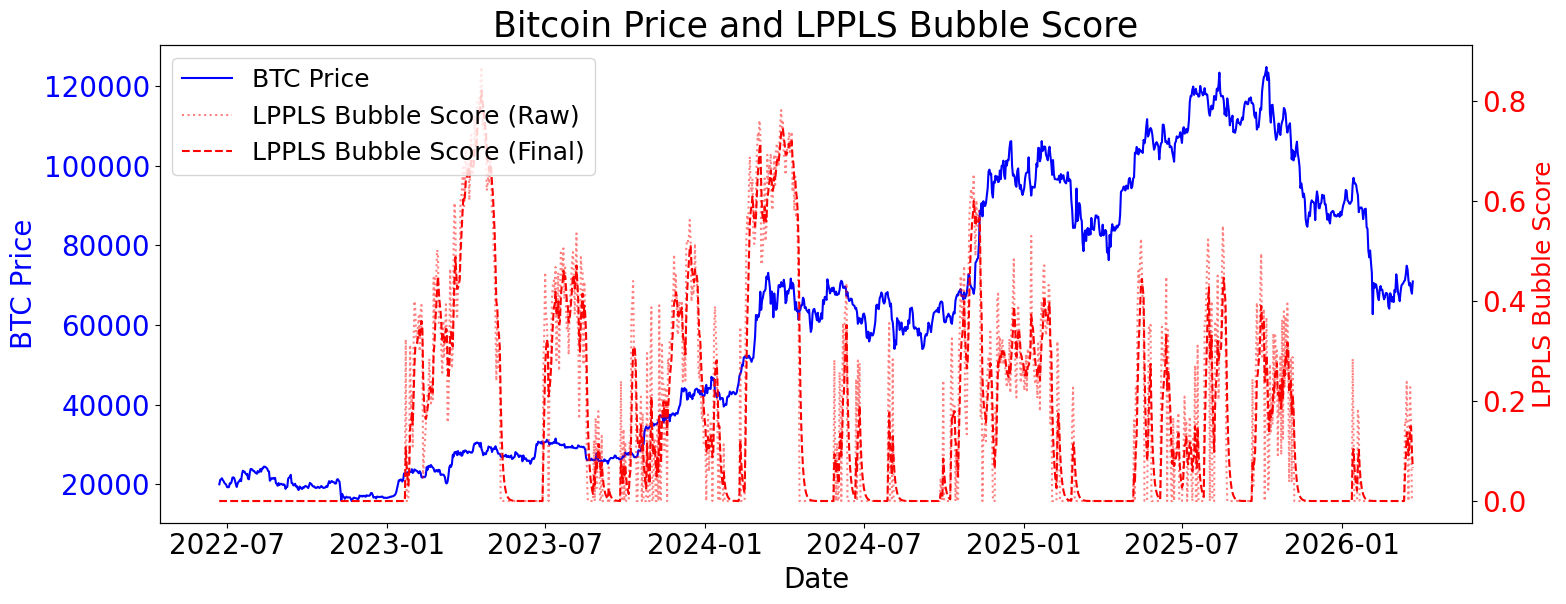

In [ ]:
import matplotlib.pyplot as plt

SMOOTH_WINDOW = 5

df['lppls_custom_final_score_smooth'] = (
    df['lppls_custom_final_score']
    .ewm(span=SMOOTH_WINDOW, adjust=False)
    .mean()
)

# ==============================
# PREP DATA FOR PLOTTING
# ==============================
df_plot = df.copy()

# ==============================
# PLOT THE RESULTS
# ==============================
fig, ax1 = plt.subplots(figsize=(15,6))

# --- PRICE ---
ax1.plot(df_plot['Date'], df_plot['BCP'], color='blue', label='BTC Price')
ax1.set_ylabel('BTC Price', fontsize=20, color='blue')
ax1.set_xlabel('Date', fontsize=20)
ax1.tick_params(axis='y', labelcolor='blue')

# --- CUSTOM FINAL SCORE ---
ax2 = ax1.twinx()
ax2.plot(
    df_plot['Date'],
    df_plot['lppls_custom_final_score'],
    linestyle=':',
    color='red', alpha=0.5, label='LPPLS Bubble Score (Raw)'
)
ax2.plot(
    df_plot['Date'],
    df_plot['lppls_custom_final_score_smooth'],
    linestyle='--',
    color='red', label='LPPLS Bubble Score (Final)'
)
ax2.set_ylabel('LPPLS Bubble Score', fontsize=18, color='red')
ax2.tick_params(axis='y', labelcolor='red')

# --- TITLE ---
plt.title('Bitcoin Price and LPPLS Bubble Score', fontsize=25)

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=18)

fig.tight_layout() # Adjust layout to prevent labels from overlapping

# Bigger tick labels
ax1.tick_params(axis='both', labelsize=20)

# Bigger tick labels
ax2.tick_params(axis='both', labelsize=20)

plt.show()


# Strategies Validation (FIRST VERSION)

## Strategies su DatasetA

In [ ]:
start_date = pd.to_datetime('2023-01-01')
df = df[df['Date'] >= start_date].reset_index(drop=True)
print(df.head())
print(df.tail())

In [ ]:
dfA = df

In [ ]:
df = dfA

In [ ]:
df['bubble_score']  = df['lppls_custom_final_score_smooth']

In [ ]:
FGI_SMOOTH_WINDOW = 10
df['FGI'] = df['FGI'].ewm(span=FGI_SMOOTH_WINDOW, adjust=False).mean()
print('FGI smoothed with a 10-day EWMA.')

In [ ]:
import matplotlib.pyplot as plt

df_plot = df.copy()

fig, ax1 = plt.subplots(figsize=(15,6))

# Plot BCP on the first y-axis
ax1.plot(df_plot['Date'], df_plot['BCP'], color='blue', label='Bitcoin Price')
ax1.set_ylabel('Bitcoin Price', color='blue', fontsize=20)
ax1.tick_params(axis='y', labelcolor='blue')

# Create a second y-axis for FGI
ax2 = ax1.twinx()
ax2.plot(df_plot['Date'], df_plot['FGI'], color='red', linestyle='--', label='Fear & Greed Index')
ax2.set_ylabel('Fear & Greed Index', color='red', fontsize=20)
ax2.tick_params(axis='y', labelcolor='red')

ax1.set_xlabel('Date', fontsize=12)
plt.title('Bitcoin Price and Fear & Greed Index', fontsize=25)

# Add legends from both axes
lines = ax1.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=20)

plt.grid(True)
plt.tight_layout()

# Bigger tick labels
ax1.tick_params(axis='both', labelsize=19)

# Bigger tick labels
ax2.tick_params(axis='both', labelsize=19)

plt.show()

### Strategia con LPPLS bubble score

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# SIMPLE STRATEGY WITH PERIODIC REBALANCING
# ============================================================

df = df.copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

PRICE_COL = 'BCP'
SCORE_COL = 'bubble_score'

fee = 0.001
REBALANCE_DAYS = 5

# ------------------------------------------------------------
# DATA PREPARATION
# ------------------------------------------------------------

df[PRICE_COL] = df[PRICE_COL].astype(float)
df[SCORE_COL] = df[SCORE_COL].ffill().fillna(0).clip(0, 1)

df['ret'] = df[PRICE_COL].pct_change().fillna(0)

# ============================================================
# STRATEGY: PERIODIC REBALANCING
# ============================================================

# Buy & Hold
df['position_bh'] = 1.0

# Compute target exposure
MAX_EXPOSURE = 1
ALPHA = 0.5

df['target_position'] = MAX_EXPOSURE * (1 - df[SCORE_COL]**ALPHA)

# Initialize actual position
positions = []
current_position = df['target_position'].iloc[0]

for i in range(len(df)):

    # rebalance every N days
    if i % REBALANCE_DAYS == 0:
        current_position = df['target_position'].iloc[i]

    positions.append(current_position)

df['position_strategy'] = positions

# ============================================================
# RETURNS
# ============================================================

def apply_strategy(df, position_col, ret_col='ret', fee=0.001):
    out = df.copy()

    trade_col = f'trade_{position_col}'
    ret_strategy_col = f'ret_{position_col}'
    equity_col = f'equity_{position_col}'

    # trades only occur at rebalancing points now
    out[trade_col] = out[position_col].diff().abs().fillna(0)

    out[ret_strategy_col] = (
        out[position_col].shift(1).fillna(out[position_col]) * out[ret_col]
    )

    out[ret_strategy_col] -= out[trade_col] * fee

    out[equity_col] = (1 + out[ret_strategy_col]).cumprod()

    return out, ret_strategy_col, equity_col, trade_col


df, ret_bh, equity_bh, trade_bh = apply_strategy(df, 'position_bh', fee=fee)
df, ret_strat, equity_strat, trade_strat = apply_strategy(df, 'position_strategy', fee=fee)

# ============================================================
# METRICS
# ============================================================

def compute_drawdown(equity):
    peak = equity.cummax()
    return (equity - peak) / peak


def compute_metrics(df, ret_col, equity_col, trade_col, position_col, name):
    ret = df[ret_col]
    equity = df[equity_col]

    total_return = equity.iloc[-1] / equity.iloc[0] - 1
    ann_return = (1 + total_return) ** (365 / len(df)) - 1
    ann_vol = ret.std() * np.sqrt(365)
    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    dd = compute_drawdown(equity)
    max_dd = dd.min()
    calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan

    return {
        'Strategy': name,
        'Final Value': equity.iloc[-1],
        'Total Return': total_return,
        'Annual Return': ann_return,
        'Annual Volatility': ann_vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd,
        'Calmar Ratio': calmar,
        'Average Exposure': df[position_col].mean(),
        'Turnover': df[trade_col].sum()
    }


metrics = pd.DataFrame([
    compute_metrics(df, ret_bh, equity_bh, trade_bh, 'position_bh', 'Buy & Hold'),
    compute_metrics(df, ret_strat, equity_strat, trade_strat, 'position_strategy', 'Rebalanced Strategy (10d)')
])

display(metrics)

# ============================================================
# DRAWDOWNS
# ============================================================

df['dd_bh'] = compute_drawdown(df[equity_bh])
df['dd_strategy'] = compute_drawdown(df[equity_strat])

# ============================================================
# PLOTS
# ============================================================

# Equity
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df[equity_bh], label='Buy & Hold', linestyle='--')
plt.plot(df['Date'], df[equity_strat], label='Rebalanced Strategy (10d)', linewidth=2)
plt.title('Equity Curve')
plt.legend()
plt.grid(True)
plt.show()

# Drawdown
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['dd_bh'], label='Buy & Hold', linestyle='--')
plt.plot(df['Date'], df['dd_strategy'], label='Rebalanced Strategy (10d)', linewidth=2)
plt.title('Drawdown')
plt.legend()
plt.grid(True)
plt.show()

# Exposure
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df[SCORE_COL], label='Bubble Score')
plt.plot(df['Date'], df['position_strategy'], label='Exposure (10d rebalanced)')
plt.title('Score vs Exposure')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ==============================
# EQUITY CURVE
# ==============================
plt.figure(figsize=(12, 6))

plt.plot(
    df['Date'],
    df[equity_bh],
    label='Buy & Hold',
    linestyle='--',
    linewidth=2
)

plt.plot(
    df['Date'],
    df[equity_strat],
    label='LPPLS Rebalanced Strategy',
    linewidth=3
)

plt.title(
    'Equity Curve',
    fontsize=25
)

plt.xlabel(
    'Date',
    fontsize=20
)

plt.ylabel(
    'Portfolio Value',
    fontsize=20
)

plt.xticks(fontsize=15)
plt.yticks(fontsize=20)

plt.legend(fontsize=18)
plt.grid(True)

plt.tight_layout()
plt.show()


# ==============================
# DRAWDOWN
# ==============================
plt.figure(figsize=(12, 6))

plt.plot(
    df['Date'],
    df['dd_bh'],
    label='Buy & Hold',
    linestyle='--',
    linewidth=2
)

plt.plot(
    df['Date'],
    df['dd_strategy'],
    label='LPPLS Rebalanced Strategy',
    linewidth=3
)

plt.title(
    'Drawdowns',
    fontsize=25
)

plt.xlabel(
    'Date',
    fontsize=20
)

plt.ylabel(
    'Drawdown',
    fontsize=20
)

plt.xticks(fontsize=15)
plt.yticks(fontsize=20)

plt.legend(fontsize=18)
plt.grid(True)

plt.tight_layout()
plt.show()


# ==============================
# SCORE VS EXPOSURE
# ==============================
plt.figure(figsize=(12, 5))

plt.plot(
    df['Date'],
    df[SCORE_COL],
    label='Bubble Score',
    linewidth=2
)

plt.plot(
    df['Date'],
    df['position_strategy'],
    label='Exposure',
    linewidth=3
)

plt.title(
    'Score and Exposure',
    fontsize=25
)

plt.xlabel(
    'Date',
    fontsize=20
)

plt.ylabel(
    'Value',
    fontsize=20
)

plt.xticks(fontsize=15)
plt.yticks(fontsize=20)

plt.legend(fontsize=18)
plt.grid(True)

plt.tight_layout()
plt.show()

### Strategia con FGI

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# FGI-BASED STRATEGY (ANALOGOUS TO BUBBLE SCORE)
# ============================================================

df = df.copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

PRICE_COL = 'BCP'
FGI_COL = 'FGI'

fee = 0.001
REBALANCE_DAYS = 5

MAX_EXPOSURE = 1
ALPHA = 1   # same nonlinear mapping used before

# ------------------------------------------------------------
# DATA PREPARATION
# ------------------------------------------------------------

df[PRICE_COL] = df[PRICE_COL].astype(float)
df[FGI_COL] = df[FGI_COL].ffill().fillna(50)

df['ret'] = df[PRICE_COL].pct_change().fillna(0)

# ============================================================
# NORMALIZE FGI
# ============================================================

df['fgi_norm'] = (df[FGI_COL] / 100).clip(0, 1)

# ============================================================
# TARGET EXPOSURE (SAME FORMULA)
# ============================================================

df['target_position_fgi'] = MAX_EXPOSURE * (1 - df['fgi_norm']**ALPHA)

# ============================================================
# PERIODIC REBALANCING
# ============================================================

positions = []
current_position = df['target_position_fgi'].iloc[0]

for i in range(len(df)):

    if i % REBALANCE_DAYS == 0:
        current_position = df['target_position_fgi'].iloc[i]

    positions.append(current_position)

df['position_fgi'] = positions

# ============================================================
# RETURNS
# ============================================================

def apply_strategy(df, position_col, ret_col='ret', fee=0.001):
    out = df.copy()

    trade_col = f'trade_{position_col}'
    ret_strategy_col = f'ret_{position_col}'
    equity_col = f'equity_{position_col}'

    out[trade_col] = out[position_col].diff().abs().fillna(0)

    out[ret_strategy_col] = (
        out[position_col].shift(1).fillna(out[position_col]) * out[ret_col]
    )

    out[ret_strategy_col] -= out[trade_col] * fee

    out[equity_col] = (1 + out[ret_strategy_col]).cumprod()

    return out, ret_strategy_col, equity_col, trade_col


# Buy & Hold
df['position_bh'] = 1.0
df, ret_bh, equity_bh, trade_bh = apply_strategy(df, 'position_bh', fee=fee)

# 80% Buy & Hold (fair comparison)
df['position_80_bh'] = 0.80
df, ret_80_bh, equity_80_bh, trade_80_bh = apply_strategy(df, 'position_80_bh', fee=fee)

# FGI strategy
df, ret_fgi, equity_fgi, trade_fgi = apply_strategy(df, 'position_fgi', fee=fee)

# ============================================================
# METRICS
# ============================================================

def compute_drawdown(equity):
    peak = equity.cummax()
    return (equity - peak) / peak


def compute_metrics(df, ret_col, equity_col, trade_col, position_col, name):
    ret = df[ret_col]
    equity = df[equity_col]

    total_return = equity.iloc[-1] / equity.iloc[0] - 1
    ann_return = (1 + total_return) ** (365 / len(df)) - 1
    ann_vol = ret.std() * np.sqrt(365)
    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    dd = compute_drawdown(equity)
    max_dd = dd.min()
    calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan

    return {
        'Strategy': name,
        'Final Value': equity.iloc[-1],
        'Total Return': total_return,
        'Annual Return': ann_return,
        'Annual Volatility': ann_vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd,
        'Calmar Ratio': calmar,
        'Average Exposure': df[position_col].mean(),
        'Turnover': df[trade_col].sum()
    }


metrics = pd.DataFrame([
    compute_metrics(df, ret_bh, equity_bh, trade_bh, 'position_bh', 'Buy & Hold'),
    compute_metrics(df, ret_80_bh, equity_80_bh, trade_80_bh, 'position_80_bh', '80% Buy & Hold'),
    compute_metrics(df, ret_fgi, equity_fgi, trade_fgi, 'position_fgi', 'FGI Strategy')
])

display(metrics)

# ============================================================
# DRAWDOWNS
# ============================================================

df['dd_bh'] = compute_drawdown(df[equity_bh])
df['dd_80_bh'] = compute_drawdown(df[equity_80_bh])
df['dd_fgi'] = compute_drawdown(df[equity_fgi])

# ============================================================
# PLOTS
# ============================================================

# Equity comparison
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df[equity_bh], label='Buy & Hold', linestyle='--')
#plt.plot(df['Date'], df[equity_80_bh], label='80% Buy & Hold')
plt.plot(df['Date'], df[equity_fgi], label='FGI Strategy', linewidth=2)
plt.title('Equity Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

# Drawdown comparison
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['dd_bh'], label='Buy & Hold', linestyle='--')
#plt.plot(df['Date'], df['dd_80_bh'], label='80% Buy & Hold')
plt.plot(df['Date'], df['dd_fgi'], label='FGI Strategy', linewidth=2)
plt.title('Drawdown Comparison')
plt.legend()
plt.grid(True)
plt.show()

# FGI vs exposure
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['fgi_norm'], label='FGI (normalized)')
plt.plot(df['Date'], df['position_fgi'], label='FGI Exposure')
plt.title('FGI vs Strategy Exposure')
plt.legend()
plt.grid(True)
plt.show()

### Strategia LPPLS*FGI con fear exit

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# LPPLS + FGI STRATEGY WITH FEAR EXIT
# ============================================================

df = df.copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

PRICE_COL = 'BCP'
BUBBLE_COL = 'bubble_score'
FGI_COL = 'FGI'

fee = 0.001
REBALANCE_DAYS = 5
MAX_EXPOSURE = 1
ALPHA = 1

# ------------------------------------------------------------
# DATA PREPARATION
# ------------------------------------------------------------

df[PRICE_COL] = df[PRICE_COL].astype(float)
df[BUBBLE_COL] = df[BUBBLE_COL].ffill().fillna(0).clip(0, 1)
df[FGI_COL] = df[FGI_COL].ffill().fillna(50)

df['ret'] = df[PRICE_COL].pct_change().fillna(0)

# ------------------------------------------------------------
# SIGNALS
# ------------------------------------------------------------

df['lppls_score'] = df[BUBBLE_COL]
df['fgi_norm'] = (df[FGI_COL] / 100).clip(0, 1)

# Greed/bubble risk: high when both LPPLS and FGI are high
df['bubble_greed_risk'] = (df['lppls_score'] * df['fgi_norm'])**(0.5)

# Fear risk: high when FGI is low
df['fear_risk'] = 1 - df['fgi_norm']

# Final risk score: risk is high either in euphoric bubble or panic/fear
df['risk_score'] = np.maximum(df['bubble_greed_risk'], df['fear_risk']).clip(0, 1)

# ------------------------------------------------------------
# TARGET EXPOSURE
# ------------------------------------------------------------

df['target_position_risk'] = MAX_EXPOSURE * (1 - df['risk_score']**ALPHA)

# ------------------------------------------------------------
# PERIODIC REBALANCING
# ------------------------------------------------------------

positions = []
current_position = df['target_position_risk'].iloc[0]

for i in range(len(df)):
    if i % REBALANCE_DAYS == 0:
        current_position = df['target_position_risk'].iloc[i]
    positions.append(current_position)

df['position_risk'] = positions

# ------------------------------------------------------------
# APPLY STRATEGY
# ------------------------------------------------------------

def apply_strategy(df, position_col, ret_col='ret', fee=0.001):
    out = df.copy()

    trade_col = f'trade_{position_col}'
    ret_strategy_col = f'ret_{position_col}'
    equity_col = f'equity_{position_col}'

    out[trade_col] = out[position_col].diff().abs().fillna(0)

    out[ret_strategy_col] = (
        out[position_col].shift(1).fillna(out[position_col]) * out[ret_col]
    )

    out[ret_strategy_col] -= out[trade_col] * fee
    out[equity_col] = (1 + out[ret_strategy_col]).cumprod()

    return out, ret_strategy_col, equity_col, trade_col

# ------------------------------------------------------------
# BENCHMARKS
# ------------------------------------------------------------

df['position_bh'] = 1.0
df['position_80_bh'] = 0.80

df, ret_bh, equity_bh, trade_bh = apply_strategy(df, 'position_bh', fee=fee)
df, ret_80_bh, equity_80_bh, trade_80_bh = apply_strategy(df, 'position_80_bh', fee=fee)
df, ret_risk, equity_risk, trade_risk = apply_strategy(df, 'position_risk', fee=fee)

# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

def compute_drawdown(equity):
    peak = equity.cummax()
    return (equity - peak) / peak


def compute_metrics(df, ret_col, equity_col, trade_col, position_col, name):
    ret = df[ret_col]
    equity = df[equity_col]

    total_return = equity.iloc[-1] / equity.iloc[0] - 1
    ann_return = (1 + total_return) ** (365 / len(df)) - 1
    ann_vol = ret.std() * np.sqrt(365)
    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    dd = compute_drawdown(equity)
    max_dd = dd.min()
    calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan

    return {
        'Strategy': name,
        'Final Value': equity.iloc[-1],
        'Total Return': total_return,
        'Annual Return': ann_return,
        'Annual Volatility': ann_vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd,
        'Calmar Ratio': calmar,
        'Average Exposure': df[position_col].mean(),
        'Turnover': df[trade_col].sum()
    }


metrics = pd.DataFrame([
    compute_metrics(df, ret_bh, equity_bh, trade_bh, 'position_bh', 'Buy & Hold'),
    compute_metrics(df, ret_80_bh, equity_80_bh, trade_80_bh, 'position_80_bh', '80% Buy & Hold'),
    compute_metrics(df, ret_risk, equity_risk, trade_risk, 'position_risk', 'LPPLS × FGI + Fear Exit')
])

display(metrics)

# ------------------------------------------------------------
# DRAWDOWNS
# ------------------------------------------------------------

df['dd_bh'] = compute_drawdown(df[equity_bh])
df['dd_80_bh'] = compute_drawdown(df[equity_80_bh])
df['dd_risk'] = compute_drawdown(df[equity_risk])

# ------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df[equity_bh], label='Buy & Hold', linestyle='--')
#plt.plot(df['Date'], df[equity_80_bh], label='80% Buy & Hold')
plt.plot(df['Date'], df[equity_risk], label='LPPLS × FGI + Fear Exit', linewidth=2)
plt.title('Equity Curve Comparison')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['dd_bh'], label='Buy & Hold', linestyle='--')
#plt.plot(df['Date'], df['dd_80_bh'], label='80% Buy & Hold')
plt.plot(df['Date'], df['dd_risk'], label='LPPLS × FGI + Fear Exit', linewidth=2)
plt.title('Drawdown Comparison')
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['bubble_greed_risk'], label='Bubble-Greed Risk')
plt.plot(df['Date'], df['fear_risk'], label='Fear Risk')
plt.plot(df['Date'], df['risk_score'], label='Final Risk Score', linewidth=2)
plt.title('Risk Components')
plt.xlabel('Date')
plt.ylabel('Risk')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['risk_score'], label='Risk Score')
plt.plot(df['Date'], df['position_risk'], label='BTC Exposure')
plt.title('Risk Score and Portfolio Exposure')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

### Stesso con composizione additiva LBS e FGI

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# LPPLS + FGI STRATEGY WITH FEAR EXIT
# ============================================================

df = df.copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

PRICE_COL = 'BCP'
BUBBLE_COL = 'bubble_score'
FGI_COL = 'FGI'

fee = 0.001
REBALANCE_DAYS = 5
MAX_EXPOSURE = 1
ALPHA = 1

# ------------------------------------------------------------
# DATA PREPARATION
# ------------------------------------------------------------

df[PRICE_COL] = df[PRICE_COL].astype(float)
df[BUBBLE_COL] = df[BUBBLE_COL].ffill().fillna(0).clip(0, 1)
df[FGI_COL] = df[FGI_COL].ffill().fillna(50)

df['ret'] = df[PRICE_COL].pct_change().fillna(0)

# ------------------------------------------------------------
# SIGNALS
# ------------------------------------------------------------

df['lppls_score'] = df[BUBBLE_COL]
df['fgi_norm'] = (df[FGI_COL] / 100).clip(0, 1)

# Greed/bubble risk: high when both LPPLS and FGI are high
df['bubble_greed_risk'] = 0.5*df['lppls_score'] + 0.5*df['fgi_norm']

# Fear risk: high when FGI is low
df['fear_risk'] = 1 - df['fgi_norm']

# Final risk score: risk is high either in euphoric bubble or panic/fear
df['risk_score'] = np.maximum(df['bubble_greed_risk'], df['fear_risk']).clip(0, 1)

# ------------------------------------------------------------
# TARGET EXPOSURE
# ------------------------------------------------------------

df['target_position_risk'] = MAX_EXPOSURE * (1 - df['risk_score']**ALPHA)

# ------------------------------------------------------------
# PERIODIC REBALANCING
# ------------------------------------------------------------

positions = []
current_position = df['target_position_risk'].iloc[0]

for i in range(len(df)):
    if i % REBALANCE_DAYS == 0:
        current_position = df['target_position_risk'].iloc[i]
    positions.append(current_position)

df['position_risk'] = positions

# ------------------------------------------------------------
# APPLY STRATEGY
# ------------------------------------------------------------

def apply_strategy(df, position_col, ret_col='ret', fee=0.001):
    out = df.copy()

    trade_col = f'trade_{position_col}'
    ret_strategy_col = f'ret_{position_col}'
    equity_col = f'equity_{position_col}'

    out[trade_col] = out[position_col].diff().abs().fillna(0)

    out[ret_strategy_col] = (
        out[position_col].shift(1).fillna(out[position_col]) * out[ret_col]
    )

    out[ret_strategy_col] -= out[trade_col] * fee
    out[equity_col] = (1 + out[ret_strategy_col]).cumprod()

    return out, ret_strategy_col, equity_col, trade_col

# ------------------------------------------------------------
# BENCHMARKS
# ------------------------------------------------------------

df['position_bh'] = 1.0
df['position_80_bh'] = 0.80

df, ret_bh, equity_bh, trade_bh = apply_strategy(df, 'position_bh', fee=fee)
df, ret_80_bh, equity_80_bh, trade_80_bh = apply_strategy(df, 'position_80_bh', fee=fee)
df, ret_risk, equity_risk, trade_risk = apply_strategy(df, 'position_risk', fee=fee)

# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

def compute_drawdown(equity):
    peak = equity.cummax()
    return (equity - peak) / peak


def compute_metrics(df, ret_col, equity_col, trade_col, position_col, name):
    ret = df[ret_col]
    equity = df[equity_col]

    total_return = equity.iloc[-1] / equity.iloc[0] - 1
    ann_return = (1 + total_return) ** (365 / len(df)) - 1
    ann_vol = ret.std() * np.sqrt(365)
    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    dd = compute_drawdown(equity)
    max_dd = dd.min()
    calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan

    return {
        'Strategy': name,
        'Final Value': equity.iloc[-1],
        'Total Return': total_return,
        'Annual Return': ann_return,
        'Annual Volatility': ann_vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd,
        'Calmar Ratio': calmar,
        'Average Exposure': df[position_col].mean(),
        'Turnover': df[trade_col].sum()
    }


metrics = pd.DataFrame([
    compute_metrics(df, ret_bh, equity_bh, trade_bh, 'position_bh', 'Buy & Hold'),
    compute_metrics(df, ret_80_bh, equity_80_bh, trade_80_bh, 'position_80_bh', '80% Buy & Hold'),
    compute_metrics(df, ret_risk, equity_risk, trade_risk, 'position_risk', 'LPPLS × FGI + Fear Exit')
])

display(metrics)

# ------------------------------------------------------------
# DRAWDOWNS
# ------------------------------------------------------------

df['dd_bh'] = compute_drawdown(df[equity_bh])
df['dd_80_bh'] = compute_drawdown(df[equity_80_bh])
df['dd_risk'] = compute_drawdown(df[equity_risk])

# ------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df[equity_bh], label='Buy & Hold', linestyle='--')
#plt.plot(df['Date'], df[equity_80_bh], label='80% Buy & Hold')
plt.plot(df['Date'], df[equity_risk], label='LPPLS × FGI + Fear Exit', linewidth=2)
plt.title('Equity Curve Comparison')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['dd_bh'], label='Buy & Hold', linestyle='--')
#plt.plot(df['Date'], df['dd_80_bh'], label='80% Buy & Hold')
plt.plot(df['Date'], df['dd_risk'], label='LPPLS × FGI + Fear Exit', linewidth=2)
plt.title('Drawdown Comparison')
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['bubble_greed_risk'], label='Bubble-Greed Risk')
plt.plot(df['Date'], df['fear_risk'], label='Fear Risk')
plt.plot(df['Date'], df['risk_score'], label='Final Risk Score', linewidth=2)
plt.title('Risk Components')
plt.xlabel('Date')
plt.ylabel('Risk')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['risk_score'], label='Risk Score')
plt.plot(df['Date'], df['position_risk'], label='BTC Exposure')
plt.title('Risk Score and Portfolio Exposure')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

### Volatility Targeting

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# ADAPTIVE VOLATILITY TARGETING STRATEGY
# ============================================================

df = df.copy()
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

PRICE_COL = "BCP"

INITIAL_CAPITAL = 1.0
FEE = 0.001
REBALANCE_DAYS = 5

VOL_WINDOW = 30
TARGET_VOL_WINDOW = 180
TARGET_VOL_PERCENTILE = 0.15
TRADING_DAYS = 365

# ------------------------------------------------------------
# RETURNS
# ------------------------------------------------------------

df["btc_return"] = df[PRICE_COL].pct_change().fillna(0)

# ------------------------------------------------------------
# REALIZED VOLATILITY
# ------------------------------------------------------------

df["realized_vol"] = (
    df["btc_return"]
    .rolling(VOL_WINDOW)
    .std()
    * np.sqrt(TRADING_DAYS)
)

# ------------------------------------------------------------
# ADAPTIVE TARGET VOLATILITY
# ------------------------------------------------------------

df["target_vol"] = (
    df["realized_vol"]
    .rolling(TARGET_VOL_WINDOW, min_periods=VOL_WINDOW)
    .quantile(TARGET_VOL_PERCENTILE)
)

df["target_vol"] = df["target_vol"].fillna(
    df["realized_vol"]
    .expanding(min_periods=VOL_WINDOW)
    .quantile(TARGET_VOL_PERCENTILE)
)

df["target_vol"] = df["target_vol"].fillna(
    df["realized_vol"].quantile(TARGET_VOL_PERCENTILE)
)

# ------------------------------------------------------------
# TARGET EXPOSURE
# ------------------------------------------------------------

df["vol_target_weight_raw"] = df["target_vol"] / df["realized_vol"]

df["vol_target_weight_raw"] = (
    df["vol_target_weight_raw"]
    .replace([np.inf, -np.inf], np.nan)
    .clip(0, 1)
    .fillna(1.0)
)

# ------------------------------------------------------------
# REBALANCING EVERY 5 DAYS
# ------------------------------------------------------------

df["vol_target_weight"] = np.nan

current_weight = 1.0

for i in range(len(df)):
    if i % REBALANCE_DAYS == 0:
        current_weight = df.loc[i, "vol_target_weight_raw"]
    df.loc[i, "vol_target_weight"] = current_weight

# ------------------------------------------------------------
# STRATEGY RETURNS WITH TRANSACTION COSTS
# ------------------------------------------------------------

df["vol_weight_lag"] = df["vol_target_weight"].shift(1).fillna(1.0)

df["vol_turnover"] = (
    df["vol_target_weight"] - df["vol_weight_lag"]
).abs()

df["vol_transaction_cost"] = FEE * df["vol_turnover"]

df["strat_vol_return"] = (
    df["vol_weight_lag"] * df["btc_return"]
    - df["vol_transaction_cost"]
)

# ------------------------------------------------------------
# EQUITY CURVES
# ------------------------------------------------------------

df["equity_vol"] = INITIAL_CAPITAL * (1 + df["strat_vol_return"]).cumprod()
df["equity_bh"] = INITIAL_CAPITAL * (1 + df["btc_return"]).cumprod()

# ------------------------------------------------------------
# DRAWDOWNS
# ------------------------------------------------------------

df["dd_vol"] = df["equity_vol"] / df["equity_vol"].cummax() - 1
df["dd_bh"] = df["equity_bh"] / df["equity_bh"].cummax() - 1

# ------------------------------------------------------------
# PERFORMANCE FUNCTION
# ------------------------------------------------------------

def performance_metrics(data, equity_col, return_col, exposure_col=None):
    total_return = data[equity_col].iloc[-1] / data[equity_col].iloc[0] - 1

    n_days = len(data)

    ann_return = (1 + total_return) ** (TRADING_DAYS / n_days) - 1
    ann_vol = data[return_col].std() * np.sqrt(TRADING_DAYS)

    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    max_drawdown = (
        data[equity_col] / data[equity_col].cummax() - 1
    ).min()

    avg_exposure = data[exposure_col].mean() if exposure_col is not None else 1.0

    return {
        "Total Return": total_return,
        "Average Exposure": avg_exposure,
        "Annualized Return": ann_return,
        "Annualized Volatility": ann_vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_drawdown
    }

# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

results = pd.DataFrame({
    "BUY&HOLD": performance_metrics(
        df,
        equity_col="equity_bh",
        return_col="btc_return",
        exposure_col=None
    ),
    "STRAT VOL": performance_metrics(
        df,
        equity_col="equity_vol",
        return_col="strat_vol_return",
        exposure_col="vol_target_weight"
    )
}).T

print("===== PERFORMANCE COMPARISON =====")
display(results)

print(f"\nTarget volatility percentile: {TARGET_VOL_PERCENTILE:.0%}")

# ------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["realized_vol"], label="Realized Volatility")
plt.plot(df["Date"], df["target_vol"], label="Adaptive Target Volatility", linewidth=2)
plt.title("Realized Volatility and Adaptive Target Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["vol_target_weight"], label="STRAT VOL Exposure")
plt.title("Adaptive Volatility Targeting Exposure")
plt.xlabel("Date")
plt.ylabel("Bitcoin Allocation")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["equity_bh"], label="BUY&HOLD", linestyle="--")
plt.plot(df["Date"], df["equity_vol"], label="STRAT VOL", linewidth=2)
plt.title("Equity Curve Comparison")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["dd_bh"], label="BUY&HOLD", linestyle="--")
plt.plot(df["Date"], df["dd_vol"], label="STRAT VOL", linewidth=2)
plt.title("Drawdown Comparison")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.show()

### Trend Following

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# TREND-FOLLOWING STRATEGY
# ============================================================

df = df.copy()
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

PRICE_COL = "BCP"

INITIAL_CAPITAL = 1.0
FEE = 0.001
REBALANCE_DAYS = 5
TRADING_DAYS = 365

SHORT_MA_WINDOW = 30
LONG_MA_WINDOW = 90
GAMMA = 10

# ------------------------------------------------------------
# RETURNS
# ------------------------------------------------------------

df["btc_return"] = df[PRICE_COL].pct_change().fillna(0)

# ------------------------------------------------------------
# MOVING AVERAGES AND TREND SIGNAL
# ------------------------------------------------------------

df["ma_short"] = df[PRICE_COL].rolling(SHORT_MA_WINDOW, min_periods=1).mean()
df["ma_long"] = df[PRICE_COL].rolling(LONG_MA_WINDOW, min_periods=1).mean()

df["trend_signal"] = (
    (df["ma_short"] - df["ma_long"]) / df["ma_long"]
).replace([np.inf, -np.inf], np.nan).fillna(0)

# ------------------------------------------------------------
# TARGET EXPOSURE
# ------------------------------------------------------------

df["trend_weight_raw"] = 0.5 * (1 + np.tanh(GAMMA * df["trend_signal"]))
df["trend_weight_raw"] = df["trend_weight_raw"].clip(0, 1)

# ------------------------------------------------------------
# REBALANCING EVERY 5 DAYS
# ------------------------------------------------------------

df["trend_weight"] = np.nan
current_weight = 1.0

for i in range(len(df)):
    if i % REBALANCE_DAYS == 0:
        current_weight = df.loc[i, "trend_weight_raw"]
    df.loc[i, "trend_weight"] = current_weight

# ------------------------------------------------------------
# STRATEGY RETURNS WITH TRANSACTION COSTS
# ------------------------------------------------------------

df["trend_weight_lag"] = df["trend_weight"].shift(1).fillna(1.0)

df["trend_turnover"] = (
    df["trend_weight"] - df["trend_weight_lag"]
).abs()

df["trend_transaction_cost"] = FEE * df["trend_turnover"]

df["strat_trend_return"] = (
    df["trend_weight_lag"] * df["btc_return"]
    - df["trend_transaction_cost"]
)

# ------------------------------------------------------------
# EQUITY CURVES
# ------------------------------------------------------------

df["equity_trend"] = INITIAL_CAPITAL * (1 + df["strat_trend_return"]).cumprod()
df["equity_bh"] = INITIAL_CAPITAL * (1 + df["btc_return"]).cumprod()

# ------------------------------------------------------------
# DRAWDOWNS
# ------------------------------------------------------------

df["dd_trend"] = df["equity_trend"] / df["equity_trend"].cummax() - 1
df["dd_bh"] = df["equity_bh"] / df["equity_bh"].cummax() - 1

# ------------------------------------------------------------
# PERFORMANCE FUNCTION
# ------------------------------------------------------------

def performance_metrics(data, equity_col, return_col, exposure_col=None):
    total_return = data[equity_col].iloc[-1] / data[equity_col].iloc[0] - 1

    n_days = len(data)
    ann_return = (1 + total_return) ** (TRADING_DAYS / n_days) - 1
    ann_vol = data[return_col].std() * np.sqrt(TRADING_DAYS)

    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    max_drawdown = (
        data[equity_col] / data[equity_col].cummax() - 1
    ).min()

    avg_exposure = data[exposure_col].mean() if exposure_col is not None else 1.0

    return {
        "Total Return": total_return,
        "Average Exposure": avg_exposure,
        "Annualized Return": ann_return,
        "Annualized Volatility": ann_vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_drawdown
    }

# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

results = pd.DataFrame({
    "BUY&HOLD": performance_metrics(
        df,
        equity_col="equity_bh",
        return_col="btc_return",
        exposure_col=None
    ),
    "STRAT TREND": performance_metrics(
        df,
        equity_col="equity_trend",
        return_col="strat_trend_return",
        exposure_col="trend_weight"
    )
}).T

print("===== PERFORMANCE COMPARISON =====")
display(results)

# ------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df[PRICE_COL], label="Bitcoin Price")
plt.plot(df["Date"], df["ma_short"], label=f"MA {SHORT_MA_WINDOW}")
plt.plot(df["Date"], df["ma_long"], label=f"MA {LONG_MA_WINDOW}")
plt.title("Bitcoin Price and Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["trend_signal"], label="Trend Signal")
plt.axhline(0, linestyle="--", label="Neutral Trend")
plt.title("Normalized Trend Signal")
plt.xlabel("Date")
plt.ylabel("Trend Signal")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["trend_weight"], label="STRAT TREND Exposure")
plt.title("Trend-Following Exposure")
plt.xlabel("Date")
plt.ylabel("Bitcoin Allocation")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["equity_bh"], label="BUY&HOLD", linestyle="--")
plt.plot(df["Date"], df["equity_trend"], label="STRAT TREND", linewidth=2)
plt.title("Equity Curve Comparison")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["dd_bh"], label="BUY&HOLD", linestyle="--")
plt.plot(df["Date"], df["dd_trend"], label="STRAT TREND", linewidth=2)
plt.title("Drawdown Comparison")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.show()

## Strategies su DatasetB

In [ ]:
start_date = pd.to_datetime('2024-07-01')
dfB = df[df['Date'] >= start_date].reset_index(drop=True)
print(df.head())
print(df.tail())

In [ ]:
df = dfB

### Strategia con LPPLS bubble score

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# SIMPLE STRATEGY WITH PERIODIC REBALANCING
# ============================================================

df = df.copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

PRICE_COL = 'BCP'
SCORE_COL = 'bubble_score'

fee = 0.001
REBALANCE_DAYS = 5

# ------------------------------------------------------------
# DATA PREPARATION
# ------------------------------------------------------------

df[PRICE_COL] = df[PRICE_COL].astype(float)
df[SCORE_COL] = df[SCORE_COL].ffill().fillna(0).clip(0, 1)

df['ret'] = df[PRICE_COL].pct_change().fillna(0)

# ============================================================
# STRATEGY: PERIODIC REBALANCING
# ============================================================

# Buy & Hold
df['position_bh'] = 1.0

# Compute target exposure
MAX_EXPOSURE = 1
ALPHA = 0.5

df['target_position'] = MAX_EXPOSURE * (1 - df[SCORE_COL]**ALPHA)

# Initialize actual position
positions = []
current_position = df['target_position'].iloc[0]

for i in range(len(df)):

    # rebalance every N days
    if i % REBALANCE_DAYS == 0:
        current_position = df['target_position'].iloc[i]

    positions.append(current_position)

df['position_strategy'] = positions

# ============================================================
# RETURNS
# ============================================================

def apply_strategy(df, position_col, ret_col='ret', fee=0.001):
    out = df.copy()

    trade_col = f'trade_{position_col}'
    ret_strategy_col = f'ret_{position_col}'
    equity_col = f'equity_{position_col}'

    # trades only occur at rebalancing points now
    out[trade_col] = out[position_col].diff().abs().fillna(0)

    out[ret_strategy_col] = (
        out[position_col].shift(1).fillna(out[position_col]) * out[ret_col]
    )

    out[ret_strategy_col] -= out[trade_col] * fee

    out[equity_col] = (1 + out[ret_strategy_col]).cumprod()

    return out, ret_strategy_col, equity_col, trade_col


df, ret_bh, equity_bh, trade_bh = apply_strategy(df, 'position_bh', fee=fee)
df, ret_strat, equity_strat, trade_strat = apply_strategy(df, 'position_strategy', fee=fee)

# ============================================================
# METRICS
# ============================================================

def compute_drawdown(equity):
    peak = equity.cummax()
    return (equity - peak) / peak


def compute_metrics(df, ret_col, equity_col, trade_col, position_col, name):
    ret = df[ret_col]
    equity = df[equity_col]

    total_return = equity.iloc[-1] / equity.iloc[0] - 1
    ann_return = (1 + total_return) ** (365 / len(df)) - 1
    ann_vol = ret.std() * np.sqrt(365)
    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    dd = compute_drawdown(equity)
    max_dd = dd.min()
    calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan

    return {
        'Strategy': name,
        'Final Value': equity.iloc[-1],
        'Total Return': total_return,
        'Annual Return': ann_return,
        'Annual Volatility': ann_vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd,
        'Calmar Ratio': calmar,
        'Average Exposure': df[position_col].mean(),
        'Turnover': df[trade_col].sum()
    }


metrics = pd.DataFrame([
    compute_metrics(df, ret_bh, equity_bh, trade_bh, 'position_bh', 'Buy & Hold'),
    compute_metrics(df, ret_strat, equity_strat, trade_strat, 'position_strategy', 'Rebalanced Strategy (10d)')
])

display(metrics)

# ============================================================
# DRAWDOWNS
# ============================================================

df['dd_bh'] = compute_drawdown(df[equity_bh])
df['dd_strategy'] = compute_drawdown(df[equity_strat])

# ============================================================
# PLOTS
# ============================================================

# Equity
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df[equity_bh], label='Buy & Hold', linestyle='--')
plt.plot(df['Date'], df[equity_strat], label='Rebalanced Strategy (10d)', linewidth=2)
plt.title('Equity Curve')
plt.legend()
plt.grid(True)
plt.show()

# Drawdown
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['dd_bh'], label='Buy & Hold', linestyle='--')
plt.plot(df['Date'], df['dd_strategy'], label='Rebalanced Strategy (10d)', linewidth=2)
plt.title('Drawdown')
plt.legend()
plt.grid(True)
plt.show()

# Exposure
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df[SCORE_COL], label='Bubble Score')
plt.plot(df['Date'], df['position_strategy'], label='Exposure (10d rebalanced)')
plt.title('Score vs Exposure')
plt.legend()
plt.grid(True)
plt.show()

### Strategia con FGI

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# FGI-BASED STRATEGY (ANALOGOUS TO BUBBLE SCORE)
# ============================================================

df = df.copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

PRICE_COL = 'BCP'
FGI_COL = 'FGI'

fee = 0.001
REBALANCE_DAYS = 5

MAX_EXPOSURE = 1
ALPHA = 1   # same nonlinear mapping used before

# ------------------------------------------------------------
# DATA PREPARATION
# ------------------------------------------------------------

df[PRICE_COL] = df[PRICE_COL].astype(float)
df[FGI_COL] = df[FGI_COL].ffill().fillna(50)

df['ret'] = df[PRICE_COL].pct_change().fillna(0)

# ============================================================
# NORMALIZE FGI
# ============================================================

df['fgi_norm'] = (df[FGI_COL] / 100).clip(0, 1)

# ============================================================
# TARGET EXPOSURE (SAME FORMULA)
# ============================================================

df['target_position_fgi'] = MAX_EXPOSURE * (1 - df['fgi_norm']**ALPHA)

# ============================================================
# PERIODIC REBALANCING
# ============================================================

positions = []
current_position = df['target_position_fgi'].iloc[0]

for i in range(len(df)):

    if i % REBALANCE_DAYS == 0:
        current_position = df['target_position_fgi'].iloc[i]

    positions.append(current_position)

df['position_fgi'] = positions

# ============================================================
# RETURNS
# ============================================================

def apply_strategy(df, position_col, ret_col='ret', fee=0.001):
    out = df.copy()

    trade_col = f'trade_{position_col}'
    ret_strategy_col = f'ret_{position_col}'
    equity_col = f'equity_{position_col}'

    out[trade_col] = out[position_col].diff().abs().fillna(0)

    out[ret_strategy_col] = (
        out[position_col].shift(1).fillna(out[position_col]) * out[ret_col]
    )

    out[ret_strategy_col] -= out[trade_col] * fee

    out[equity_col] = (1 + out[ret_strategy_col]).cumprod()

    return out, ret_strategy_col, equity_col, trade_col


# Buy & Hold
df['position_bh'] = 1.0
df, ret_bh, equity_bh, trade_bh = apply_strategy(df, 'position_bh', fee=fee)

# 80% Buy & Hold (fair comparison)
df['position_80_bh'] = 0.80
df, ret_80_bh, equity_80_bh, trade_80_bh = apply_strategy(df, 'position_80_bh', fee=fee)

# FGI strategy
df, ret_fgi, equity_fgi, trade_fgi = apply_strategy(df, 'position_fgi', fee=fee)

# ============================================================
# METRICS
# ============================================================

def compute_drawdown(equity):
    peak = equity.cummax()
    return (equity - peak) / peak


def compute_metrics(df, ret_col, equity_col, trade_col, position_col, name):
    ret = df[ret_col]
    equity = df[equity_col]

    total_return = equity.iloc[-1] / equity.iloc[0] - 1
    ann_return = (1 + total_return) ** (365 / len(df)) - 1
    ann_vol = ret.std() * np.sqrt(365)
    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    dd = compute_drawdown(equity)
    max_dd = dd.min()
    calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan

    return {
        'Strategy': name,
        'Final Value': equity.iloc[-1],
        'Total Return': total_return,
        'Annual Return': ann_return,
        'Annual Volatility': ann_vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd,
        'Calmar Ratio': calmar,
        'Average Exposure': df[position_col].mean(),
        'Turnover': df[trade_col].sum()
    }


metrics = pd.DataFrame([
    compute_metrics(df, ret_bh, equity_bh, trade_bh, 'position_bh', 'Buy & Hold'),
    compute_metrics(df, ret_80_bh, equity_80_bh, trade_80_bh, 'position_80_bh', '80% Buy & Hold'),
    compute_metrics(df, ret_fgi, equity_fgi, trade_fgi, 'position_fgi', 'FGI Strategy')
])

display(metrics)

# ============================================================
# DRAWDOWNS
# ============================================================

df['dd_bh'] = compute_drawdown(df[equity_bh])
df['dd_80_bh'] = compute_drawdown(df[equity_80_bh])
df['dd_fgi'] = compute_drawdown(df[equity_fgi])

# ============================================================
# PLOTS
# ============================================================

# Equity comparison
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df[equity_bh], label='Buy & Hold', linestyle='--')
#plt.plot(df['Date'], df[equity_80_bh], label='80% Buy & Hold')
plt.plot(df['Date'], df[equity_fgi], label='FGI Strategy', linewidth=2)
plt.title('Equity Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

# Drawdown comparison
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['dd_bh'], label='Buy & Hold', linestyle='--')
#plt.plot(df['Date'], df['dd_80_bh'], label='80% Buy & Hold')
plt.plot(df['Date'], df['dd_fgi'], label='FGI Strategy', linewidth=2)
plt.title('Drawdown Comparison')
plt.legend()
plt.grid(True)
plt.show()

# FGI vs exposure
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['fgi_norm'], label='FGI (normalized)')
plt.plot(df['Date'], df['position_fgi'], label='FGI Exposure')
plt.title('FGI vs Strategy Exposure')
plt.legend()
plt.grid(True)
plt.show()

### Strategia LPPLS*FGI con fear exit

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# LPPLS + FGI STRATEGY WITH FEAR EXIT
# ============================================================

df = df.copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

PRICE_COL = 'BCP'
BUBBLE_COL = 'bubble_score'
FGI_COL = 'FGI'

fee = 0.001
REBALANCE_DAYS = 5
MAX_EXPOSURE = 1
ALPHA = 1

# ------------------------------------------------------------
# DATA PREPARATION
# ------------------------------------------------------------

df[PRICE_COL] = df[PRICE_COL].astype(float)
df[BUBBLE_COL] = df[BUBBLE_COL].ffill().fillna(0).clip(0, 1)
df[FGI_COL] = df[FGI_COL].ffill().fillna(50)

df['ret'] = df[PRICE_COL].pct_change().fillna(0)

# ------------------------------------------------------------
# SIGNALS
# ------------------------------------------------------------

df['lppls_score'] = df[BUBBLE_COL]
df['fgi_norm'] = (df[FGI_COL] / 100).clip(0, 1)

# Greed/bubble risk: high when both LPPLS and FGI are high
df['bubble_greed_risk'] = (df['lppls_score'] * df['fgi_norm'])**(0.5)

# Fear risk: high when FGI is low
df['fear_risk'] = 1 - df['fgi_norm']

# Final risk score: risk is high either in euphoric bubble or panic/fear
df['risk_score'] = np.maximum(df['bubble_greed_risk'], df['fear_risk']).clip(0, 1)

# ------------------------------------------------------------
# TARGET EXPOSURE
# ------------------------------------------------------------

df['target_position_risk'] = MAX_EXPOSURE * (1 - df['risk_score']**ALPHA)

# ------------------------------------------------------------
# PERIODIC REBALANCING
# ------------------------------------------------------------

positions = []
current_position = df['target_position_risk'].iloc[0]

for i in range(len(df)):
    if i % REBALANCE_DAYS == 0:
        current_position = df['target_position_risk'].iloc[i]
    positions.append(current_position)

df['position_risk'] = positions

# ------------------------------------------------------------
# APPLY STRATEGY
# ------------------------------------------------------------

def apply_strategy(df, position_col, ret_col='ret', fee=0.001):
    out = df.copy()

    trade_col = f'trade_{position_col}'
    ret_strategy_col = f'ret_{position_col}'
    equity_col = f'equity_{position_col}'

    out[trade_col] = out[position_col].diff().abs().fillna(0)

    out[ret_strategy_col] = (
        out[position_col].shift(1).fillna(out[position_col]) * out[ret_col]
    )

    out[ret_strategy_col] -= out[trade_col] * fee
    out[equity_col] = (1 + out[ret_strategy_col]).cumprod()

    return out, ret_strategy_col, equity_col, trade_col

# ------------------------------------------------------------
# BENCHMARKS
# ------------------------------------------------------------

df['position_bh'] = 1.0
df['position_80_bh'] = 0.80

df, ret_bh, equity_bh, trade_bh = apply_strategy(df, 'position_bh', fee=fee)
df, ret_80_bh, equity_80_bh, trade_80_bh = apply_strategy(df, 'position_80_bh', fee=fee)
df, ret_risk, equity_risk, trade_risk = apply_strategy(df, 'position_risk', fee=fee)

# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

def compute_drawdown(equity):
    peak = equity.cummax()
    return (equity - peak) / peak


def compute_metrics(df, ret_col, equity_col, trade_col, position_col, name):
    ret = df[ret_col]
    equity = df[equity_col]

    total_return = equity.iloc[-1] / equity.iloc[0] - 1
    ann_return = (1 + total_return) ** (365 / len(df)) - 1
    ann_vol = ret.std() * np.sqrt(365)
    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    dd = compute_drawdown(equity)
    max_dd = dd.min()
    calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan

    return {
        'Strategy': name,
        'Final Value': equity.iloc[-1],
        'Total Return': total_return,
        'Annual Return': ann_return,
        'Annual Volatility': ann_vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd,
        'Calmar Ratio': calmar,
        'Average Exposure': df[position_col].mean(),
        'Turnover': df[trade_col].sum()
    }


metrics = pd.DataFrame([
    compute_metrics(df, ret_bh, equity_bh, trade_bh, 'position_bh', 'Buy & Hold'),
    compute_metrics(df, ret_80_bh, equity_80_bh, trade_80_bh, 'position_80_bh', '80% Buy & Hold'),
    compute_metrics(df, ret_risk, equity_risk, trade_risk, 'position_risk', 'LPPLS × FGI + Fear Exit')
])

display(metrics)

# ------------------------------------------------------------
# DRAWDOWNS
# ------------------------------------------------------------

df['dd_bh'] = compute_drawdown(df[equity_bh])
df['dd_80_bh'] = compute_drawdown(df[equity_80_bh])
df['dd_risk'] = compute_drawdown(df[equity_risk])

# ------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df[equity_bh], label='Buy & Hold', linestyle='--')
#plt.plot(df['Date'], df[equity_80_bh], label='80% Buy & Hold')
plt.plot(df['Date'], df[equity_risk], label='LPPLS × FGI + Fear Exit', linewidth=2)
plt.title('Equity Curve Comparison')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['dd_bh'], label='Buy & Hold', linestyle='--')
#plt.plot(df['Date'], df['dd_80_bh'], label='80% Buy & Hold')
plt.plot(df['Date'], df['dd_risk'], label='LPPLS × FGI + Fear Exit', linewidth=2)
plt.title('Drawdown Comparison')
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['bubble_greed_risk'], label='Bubble-Greed Risk')
plt.plot(df['Date'], df['fear_risk'], label='Fear Risk')
plt.plot(df['Date'], df['risk_score'], label='Final Risk Score', linewidth=2)
plt.title('Risk Components')
plt.xlabel('Date')
plt.ylabel('Risk')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['risk_score'], label='Risk Score')
plt.plot(df['Date'], df['position_risk'], label='BTC Exposure')
plt.title('Risk Score and Portfolio Exposure')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------

# ==============================
# EQUITY CURVE
# ==============================
plt.figure(figsize=(12,6))

plt.plot(
    df['Date'],
    df[equity_bh],
    label='Buy & Hold',
    linestyle='--',
    linewidth=2
)

# plt.plot(df['Date'], df[equity_80_bh], label='80% Buy & Hold')

plt.plot(
    df['Date'],
    df[equity_risk],
    label='LPPLS × FGI + Fear Exit',
    linewidth=3
)

plt.title(
    'Equity Curve Comparison',
    fontsize=22
)

plt.xlabel(
    'Date',
    fontsize=18
)

plt.ylabel(
    'Growth of $1',
    fontsize=18
)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(fontsize=16)
plt.grid(True)

plt.tight_layout()
plt.show()


# ==============================
# DRAWDOWN
# ==============================
plt.figure(figsize=(12,6))

plt.plot(
    df['Date'],
    df['dd_bh'],
    label='Buy & Hold',
    linestyle='--',
    linewidth=2
)

# plt.plot(df['Date'], df['dd_80_bh'], label='80% Buy & Hold')

plt.plot(
    df['Date'],
    df['dd_risk'],
    label='LPPLS × FGI + Fear Exit',
    linewidth=3
)

plt.title(
    'Drawdowns',
    fontsize=25
)

plt.xlabel(
    'Date',
    fontsize=20
)

plt.ylabel(
    'Drawdown',
    fontsize=20
)

plt.xticks(fontsize=15)
plt.yticks(fontsize=20)

plt.legend(fontsize=18)
plt.grid(True)

plt.tight_layout()
plt.show()


# ==============================
# RISK COMPONENTS
# ==============================
plt.figure(figsize=(12,5))

plt.plot(
    df['Date'],
    df['bubble_greed_risk'],
    label='Bubble-Greed Risk',
    linewidth=2
)

plt.plot(
    df['Date'],
    df['fear_risk'],
    label='Fear Risk',
    linewidth=2
)

plt.plot(
    df['Date'],
    df['risk_score'],
    label='Final Risk Score',
    linewidth=3
)

plt.title(
    'Risk Components',
    fontsize=22
)

plt.xlabel(
    'Date',
    fontsize=18
)

plt.ylabel(
    'Risk',
    fontsize=18
)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(fontsize=16)
plt.grid(True)

plt.tight_layout()
plt.show()


# ==============================
# RISK SCORE VS EXPOSURE
# ==============================
plt.figure(figsize=(12,5))

plt.plot(
    df['Date'],
    df['risk_score'],
    label='Risk Score',
    linewidth=2
)

plt.plot(
    df['Date'],
    df['position_risk'],
    label='BTC Exposure',
    linewidth=3
)

plt.title(
    'Risk Score and Portfolio Exposure',
    fontsize=22
)

plt.xlabel(
    'Date',
    fontsize=18
)

plt.ylabel(
    'Value',
    fontsize=18
)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(fontsize=16)
plt.grid(True)

plt.tight_layout()
plt.show()

### Stesso con composizione additiva LBS e FGI

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# LPPLS + FGI STRATEGY WITH FEAR EXIT
# ============================================================

df = df.copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

PRICE_COL = 'BCP'
BUBBLE_COL = 'bubble_score'
FGI_COL = 'FGI'

fee = 0.001
REBALANCE_DAYS = 5
MAX_EXPOSURE = 1
ALPHA = 1

# ------------------------------------------------------------
# DATA PREPARATION
# ------------------------------------------------------------

df[PRICE_COL] = df[PRICE_COL].astype(float)
df[BUBBLE_COL] = df[BUBBLE_COL].ffill().fillna(0).clip(0, 1)
df[FGI_COL] = df[FGI_COL].ffill().fillna(50)

df['ret'] = df[PRICE_COL].pct_change().fillna(0)

# ------------------------------------------------------------
# SIGNALS
# ------------------------------------------------------------

df['lppls_score'] = df[BUBBLE_COL]
df['fgi_norm'] = (df[FGI_COL] / 100).clip(0, 1)

# Greed/bubble risk: high when both LPPLS and FGI are high
df['bubble_greed_risk'] = 0.5*df['lppls_score'] + 0.5*df['fgi_norm']

# Fear risk: high when FGI is low
df['fear_risk'] = 1 - df['fgi_norm']

# Final risk score: risk is high either in euphoric bubble or panic/fear
df['risk_score'] = np.maximum(df['bubble_greed_risk'], df['fear_risk']).clip(0, 1)

# ------------------------------------------------------------
# TARGET EXPOSURE
# ------------------------------------------------------------

df['target_position_risk'] = MAX_EXPOSURE * (1 - df['risk_score']**ALPHA)

# ------------------------------------------------------------
# PERIODIC REBALANCING
# ------------------------------------------------------------

positions = []
current_position = df['target_position_risk'].iloc[0]

for i in range(len(df)):
    if i % REBALANCE_DAYS == 0:
        current_position = df['target_position_risk'].iloc[i]
    positions.append(current_position)

df['position_risk'] = positions

# ------------------------------------------------------------
# APPLY STRATEGY
# ------------------------------------------------------------

def apply_strategy(df, position_col, ret_col='ret', fee=0.001):
    out = df.copy()

    trade_col = f'trade_{position_col}'
    ret_strategy_col = f'ret_{position_col}'
    equity_col = f'equity_{position_col}'

    out[trade_col] = out[position_col].diff().abs().fillna(0)

    out[ret_strategy_col] = (
        out[position_col].shift(1).fillna(out[position_col]) * out[ret_col]
    )

    out[ret_strategy_col] -= out[trade_col] * fee
    out[equity_col] = (1 + out[ret_strategy_col]).cumprod()

    return out, ret_strategy_col, equity_col, trade_col

# ------------------------------------------------------------
# BENCHMARKS
# ------------------------------------------------------------

df['position_bh'] = 1.0
df['position_80_bh'] = 0.80

df, ret_bh, equity_bh, trade_bh = apply_strategy(df, 'position_bh', fee=fee)
df, ret_80_bh, equity_80_bh, trade_80_bh = apply_strategy(df, 'position_80_bh', fee=fee)
df, ret_risk, equity_risk, trade_risk = apply_strategy(df, 'position_risk', fee=fee)

# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

def compute_drawdown(equity):
    peak = equity.cummax()
    return (equity - peak) / peak


def compute_metrics(df, ret_col, equity_col, trade_col, position_col, name):
    ret = df[ret_col]
    equity = df[equity_col]

    total_return = equity.iloc[-1] / equity.iloc[0] - 1
    ann_return = (1 + total_return) ** (365 / len(df)) - 1
    ann_vol = ret.std() * np.sqrt(365)
    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    dd = compute_drawdown(equity)
    max_dd = dd.min()
    calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan

    return {
        'Strategy': name,
        'Final Value': equity.iloc[-1],
        'Total Return': total_return,
        'Annual Return': ann_return,
        'Annual Volatility': ann_vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd,
        'Calmar Ratio': calmar,
        'Average Exposure': df[position_col].mean(),
        'Turnover': df[trade_col].sum()
    }


metrics = pd.DataFrame([
    compute_metrics(df, ret_bh, equity_bh, trade_bh, 'position_bh', 'Buy & Hold'),
    compute_metrics(df, ret_80_bh, equity_80_bh, trade_80_bh, 'position_80_bh', '80% Buy & Hold'),
    compute_metrics(df, ret_risk, equity_risk, trade_risk, 'position_risk', 'LPPLS × FGI + Fear Exit')
])

display(metrics)

# ------------------------------------------------------------
# DRAWDOWNS
# ------------------------------------------------------------

df['dd_bh'] = compute_drawdown(df[equity_bh])
df['dd_80_bh'] = compute_drawdown(df[equity_80_bh])
df['dd_risk'] = compute_drawdown(df[equity_risk])

# ------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df[equity_bh], label='Buy & Hold', linestyle='--')
#plt.plot(df['Date'], df[equity_80_bh], label='80% Buy & Hold')
plt.plot(df['Date'], df[equity_risk], label='LPPLS × FGI + Fear Exit', linewidth=2)
plt.title('Equity Curve Comparison')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['dd_bh'], label='Buy & Hold', linestyle='--')
#plt.plot(df['Date'], df['dd_80_bh'], label='80% Buy & Hold')
plt.plot(df['Date'], df['dd_risk'], label='LPPLS × FGI + Fear Exit', linewidth=2)
plt.title('Drawdown Comparison')
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['bubble_greed_risk'], label='Bubble-Greed Risk')
plt.plot(df['Date'], df['fear_risk'], label='Fear Risk')
plt.plot(df['Date'], df['risk_score'], label='Final Risk Score', linewidth=2)
plt.title('Risk Components')
plt.xlabel('Date')
plt.ylabel('Risk')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['risk_score'], label='Risk Score')
plt.plot(df['Date'], df['position_risk'], label='BTC Exposure')
plt.title('Risk Score and Portfolio Exposure')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

### Volatility Targeting

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# ADAPTIVE VOLATILITY TARGETING STRATEGY
# ============================================================

df = df.copy()
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

PRICE_COL = "BCP"

INITIAL_CAPITAL = 1.0
FEE = 0.001
REBALANCE_DAYS = 5

VOL_WINDOW = 30
TARGET_VOL_WINDOW = 180
TARGET_VOL_PERCENTILE = 0.15
TRADING_DAYS = 365

# ------------------------------------------------------------
# RETURNS
# ------------------------------------------------------------

df["btc_return"] = df[PRICE_COL].pct_change().fillna(0)

# ------------------------------------------------------------
# REALIZED VOLATILITY
# ------------------------------------------------------------

df["realized_vol"] = (
    df["btc_return"]
    .rolling(VOL_WINDOW)
    .std()
    * np.sqrt(TRADING_DAYS)
)

# ------------------------------------------------------------
# ADAPTIVE TARGET VOLATILITY
# ------------------------------------------------------------

df["target_vol"] = (
    df["realized_vol"]
    .rolling(TARGET_VOL_WINDOW, min_periods=VOL_WINDOW)
    .quantile(TARGET_VOL_PERCENTILE)
)

df["target_vol"] = df["target_vol"].fillna(
    df["realized_vol"]
    .expanding(min_periods=VOL_WINDOW)
    .quantile(TARGET_VOL_PERCENTILE)
)

df["target_vol"] = df["target_vol"].fillna(
    df["realized_vol"].quantile(TARGET_VOL_PERCENTILE)
)

# ------------------------------------------------------------
# TARGET EXPOSURE
# ------------------------------------------------------------

df["vol_target_weight_raw"] = df["target_vol"] / df["realized_vol"]

df["vol_target_weight_raw"] = (
    df["vol_target_weight_raw"]
    .replace([np.inf, -np.inf], np.nan)
    .clip(0, 1)
    .fillna(1.0)
)

# ------------------------------------------------------------
# REBALANCING EVERY 5 DAYS
# ------------------------------------------------------------

df["vol_target_weight"] = np.nan

current_weight = 1.0

for i in range(len(df)):
    if i % REBALANCE_DAYS == 0:
        current_weight = df.loc[i, "vol_target_weight_raw"]
    df.loc[i, "vol_target_weight"] = current_weight

# ------------------------------------------------------------
# STRATEGY RETURNS WITH TRANSACTION COSTS
# ------------------------------------------------------------

df["vol_weight_lag"] = df["vol_target_weight"].shift(1).fillna(1.0)

df["vol_turnover"] = (
    df["vol_target_weight"] - df["vol_weight_lag"]
).abs()

df["vol_transaction_cost"] = FEE * df["vol_turnover"]

df["strat_vol_return"] = (
    df["vol_weight_lag"] * df["btc_return"]
    - df["vol_transaction_cost"]
)

# ------------------------------------------------------------
# EQUITY CURVES
# ------------------------------------------------------------

df["equity_vol"] = INITIAL_CAPITAL * (1 + df["strat_vol_return"]).cumprod()
df["equity_bh"] = INITIAL_CAPITAL * (1 + df["btc_return"]).cumprod()

# ------------------------------------------------------------
# DRAWDOWNS
# ------------------------------------------------------------

df["dd_vol"] = df["equity_vol"] / df["equity_vol"].cummax() - 1
df["dd_bh"] = df["equity_bh"] / df["equity_bh"].cummax() - 1

# ------------------------------------------------------------
# PERFORMANCE FUNCTION
# ------------------------------------------------------------

def performance_metrics(data, equity_col, return_col, exposure_col=None):
    total_return = data[equity_col].iloc[-1] / data[equity_col].iloc[0] - 1

    n_days = len(data)

    ann_return = (1 + total_return) ** (TRADING_DAYS / n_days) - 1
    ann_vol = data[return_col].std() * np.sqrt(TRADING_DAYS)

    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    max_drawdown = (
        data[equity_col] / data[equity_col].cummax() - 1
    ).min()

    avg_exposure = data[exposure_col].mean() if exposure_col is not None else 1.0

    return {
        "Total Return": total_return,
        "Average Exposure": avg_exposure,
        "Annualized Return": ann_return,
        "Annualized Volatility": ann_vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_drawdown
    }

# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

results = pd.DataFrame({
    "BUY&HOLD": performance_metrics(
        df,
        equity_col="equity_bh",
        return_col="btc_return",
        exposure_col=None
    ),
    "STRAT VOL": performance_metrics(
        df,
        equity_col="equity_vol",
        return_col="strat_vol_return",
        exposure_col="vol_target_weight"
    )
}).T

print("===== PERFORMANCE COMPARISON =====")
display(results)

print(f"\nTarget volatility percentile: {TARGET_VOL_PERCENTILE:.0%}")

# ------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["realized_vol"], label="Realized Volatility")
plt.plot(df["Date"], df["target_vol"], label="Adaptive Target Volatility", linewidth=2)
plt.title("Realized Volatility and Adaptive Target Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["vol_target_weight"], label="STRAT VOL Exposure")
plt.title("Adaptive Volatility Targeting Exposure")
plt.xlabel("Date")
plt.ylabel("Bitcoin Allocation")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["equity_bh"], label="BUY&HOLD", linestyle="--")
plt.plot(df["Date"], df["equity_vol"], label="STRAT VOL", linewidth=2)
plt.title("Equity Curve Comparison")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["dd_bh"], label="BUY&HOLD", linestyle="--")
plt.plot(df["Date"], df["dd_vol"], label="STRAT VOL", linewidth=2)
plt.title("Drawdown Comparison")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.show()

### Trend Following

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# TREND-FOLLOWING STRATEGY
# ============================================================

df = df.copy()
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

PRICE_COL = "BCP"

INITIAL_CAPITAL = 1.0
FEE = 0.001
REBALANCE_DAYS = 5
TRADING_DAYS = 365

SHORT_MA_WINDOW = 30
LONG_MA_WINDOW = 90
GAMMA = 10

# ------------------------------------------------------------
# RETURNS
# ------------------------------------------------------------

df["btc_return"] = df[PRICE_COL].pct_change().fillna(0)

# ------------------------------------------------------------
# MOVING AVERAGES AND TREND SIGNAL
# ------------------------------------------------------------

df["ma_short"] = df[PRICE_COL].rolling(SHORT_MA_WINDOW, min_periods=1).mean()
df["ma_long"] = df[PRICE_COL].rolling(LONG_MA_WINDOW, min_periods=1).mean()

df["trend_signal"] = (
    (df["ma_short"] - df["ma_long"]) / df["ma_long"]
).replace([np.inf, -np.inf], np.nan).fillna(0)

# ------------------------------------------------------------
# TARGET EXPOSURE
# ------------------------------------------------------------

df["trend_weight_raw"] = 0.5 * (1 + np.tanh(GAMMA * df["trend_signal"]))
df["trend_weight_raw"] = df["trend_weight_raw"].clip(0, 1)

# ------------------------------------------------------------
# REBALANCING EVERY 5 DAYS
# ------------------------------------------------------------

df["trend_weight"] = np.nan
current_weight = 1.0

for i in range(len(df)):
    if i % REBALANCE_DAYS == 0:
        current_weight = df.loc[i, "trend_weight_raw"]
    df.loc[i, "trend_weight"] = current_weight

# ------------------------------------------------------------
# STRATEGY RETURNS WITH TRANSACTION COSTS
# ------------------------------------------------------------

df["trend_weight_lag"] = df["trend_weight"].shift(1).fillna(1.0)

df["trend_turnover"] = (
    df["trend_weight"] - df["trend_weight_lag"]
).abs()

df["trend_transaction_cost"] = FEE * df["trend_turnover"]

df["strat_trend_return"] = (
    df["trend_weight_lag"] * df["btc_return"]
    - df["trend_transaction_cost"]
)

# ------------------------------------------------------------
# EQUITY CURVES
# ------------------------------------------------------------

df["equity_trend"] = INITIAL_CAPITAL * (1 + df["strat_trend_return"]).cumprod()
df["equity_bh"] = INITIAL_CAPITAL * (1 + df["btc_return"]).cumprod()

# ------------------------------------------------------------
# DRAWDOWNS
# ------------------------------------------------------------

df["dd_trend"] = df["equity_trend"] / df["equity_trend"].cummax() - 1
df["dd_bh"] = df["equity_bh"] / df["equity_bh"].cummax() - 1

# ------------------------------------------------------------
# PERFORMANCE FUNCTION
# ------------------------------------------------------------

def performance_metrics(data, equity_col, return_col, exposure_col=None):
    total_return = data[equity_col].iloc[-1] / data[equity_col].iloc[0] - 1

    n_days = len(data)
    ann_return = (1 + total_return) ** (TRADING_DAYS / n_days) - 1
    ann_vol = data[return_col].std() * np.sqrt(TRADING_DAYS)

    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    max_drawdown = (
        data[equity_col] / data[equity_col].cummax() - 1
    ).min()

    avg_exposure = data[exposure_col].mean() if exposure_col is not None else 1.0

    return {
        "Total Return": total_return,
        "Average Exposure": avg_exposure,
        "Annualized Return": ann_return,
        "Annualized Volatility": ann_vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_drawdown
    }

# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

results = pd.DataFrame({
    "BUY&HOLD": performance_metrics(
        df,
        equity_col="equity_bh",
        return_col="btc_return",
        exposure_col=None
    ),
    "STRAT TREND": performance_metrics(
        df,
        equity_col="equity_trend",
        return_col="strat_trend_return",
        exposure_col="trend_weight"
    )
}).T

print("===== PERFORMANCE COMPARISON =====")
display(results)

# ------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df[PRICE_COL], label="Bitcoin Price")
plt.plot(df["Date"], df["ma_short"], label=f"MA {SHORT_MA_WINDOW}")
plt.plot(df["Date"], df["ma_long"], label=f"MA {LONG_MA_WINDOW}")
plt.title("Bitcoin Price and Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["trend_signal"], label="Trend Signal")
plt.axhline(0, linestyle="--", label="Neutral Trend")
plt.title("Normalized Trend Signal")
plt.xlabel("Date")
plt.ylabel("Trend Signal")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["trend_weight"], label="STRAT TREND Exposure")
plt.title("Trend-Following Exposure")
plt.xlabel("Date")
plt.ylabel("Bitcoin Allocation")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["equity_bh"], label="BUY&HOLD", linestyle="--")
plt.plot(df["Date"], df["equity_trend"], label="STRAT TREND", linewidth=2)
plt.title("Equity Curve Comparison")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["dd_bh"], label="BUY&HOLD", linestyle="--")
plt.plot(df["Date"], df["dd_trend"], label="STRAT TREND", linewidth=2)
plt.title("Drawdown Comparison")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.show()

## Strategies su DatasetC

In [ ]:
start_date = pd.to_datetime('2025-01-01')
dfC = df[df['Date'] >= start_date].reset_index(drop=True)
print(df.head())
print(df.tail())

In [ ]:
df = dfC

### Strategia con LPPLS bubble score

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# SIMPLE STRATEGY WITH PERIODIC REBALANCING
# ============================================================

df = df.copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

PRICE_COL = 'BCP'
SCORE_COL = 'bubble_score'

fee = 0.001
REBALANCE_DAYS = 5

# ------------------------------------------------------------
# DATA PREPARATION
# ------------------------------------------------------------

df[PRICE_COL] = df[PRICE_COL].astype(float)
df[SCORE_COL] = df[SCORE_COL].ffill().fillna(0).clip(0, 1)

df['ret'] = df[PRICE_COL].pct_change().fillna(0)

# ============================================================
# STRATEGY: PERIODIC REBALANCING
# ============================================================

# Buy & Hold
df['position_bh'] = 1.0

# Compute target exposure
MAX_EXPOSURE = 1
ALPHA = 0.5

df['target_position'] = MAX_EXPOSURE * (1 - df[SCORE_COL]**ALPHA)

# Initialize actual position
positions = []
current_position = df['target_position'].iloc[0]

for i in range(len(df)):

    # rebalance every N days
    if i % REBALANCE_DAYS == 0:
        current_position = df['target_position'].iloc[i]

    positions.append(current_position)

df['position_strategy'] = positions

# ============================================================
# RETURNS
# ============================================================

def apply_strategy(df, position_col, ret_col='ret', fee=0.001):
    out = df.copy()

    trade_col = f'trade_{position_col}'
    ret_strategy_col = f'ret_{position_col}'
    equity_col = f'equity_{position_col}'

    # trades only occur at rebalancing points now
    out[trade_col] = out[position_col].diff().abs().fillna(0)

    out[ret_strategy_col] = (
        out[position_col].shift(1).fillna(out[position_col]) * out[ret_col]
    )

    out[ret_strategy_col] -= out[trade_col] * fee

    out[equity_col] = (1 + out[ret_strategy_col]).cumprod()

    return out, ret_strategy_col, equity_col, trade_col


df, ret_bh, equity_bh, trade_bh = apply_strategy(df, 'position_bh', fee=fee)
df, ret_strat, equity_strat, trade_strat = apply_strategy(df, 'position_strategy', fee=fee)

# ============================================================
# METRICS
# ============================================================

def compute_drawdown(equity):
    peak = equity.cummax()
    return (equity - peak) / peak


def compute_metrics(df, ret_col, equity_col, trade_col, position_col, name):
    ret = df[ret_col]
    equity = df[equity_col]

    total_return = equity.iloc[-1] / equity.iloc[0] - 1
    ann_return = (1 + total_return) ** (365 / len(df)) - 1
    ann_vol = ret.std() * np.sqrt(365)
    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    dd = compute_drawdown(equity)
    max_dd = dd.min()
    calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan

    return {
        'Strategy': name,
        'Final Value': equity.iloc[-1],
        'Total Return': total_return,
        'Annual Return': ann_return,
        'Annual Volatility': ann_vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd,
        'Calmar Ratio': calmar,
        'Average Exposure': df[position_col].mean(),
        'Turnover': df[trade_col].sum()
    }


metrics = pd.DataFrame([
    compute_metrics(df, ret_bh, equity_bh, trade_bh, 'position_bh', 'Buy & Hold'),
    compute_metrics(df, ret_strat, equity_strat, trade_strat, 'position_strategy', 'Rebalanced Strategy (10d)')
])

display(metrics)

# ============================================================
# DRAWDOWNS
# ============================================================

df['dd_bh'] = compute_drawdown(df[equity_bh])
df['dd_strategy'] = compute_drawdown(df[equity_strat])

# ============================================================
# PLOTS
# ============================================================

# Equity
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df[equity_bh], label='Buy & Hold', linestyle='--')
plt.plot(df['Date'], df[equity_strat], label='Rebalanced Strategy (10d)', linewidth=2)
plt.title('Equity Curve')
plt.legend()
plt.grid(True)
plt.show()

# Drawdown
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['dd_bh'], label='Buy & Hold', linestyle='--')
plt.plot(df['Date'], df['dd_strategy'], label='Rebalanced Strategy (10d)', linewidth=2)
plt.title('Drawdown')
plt.legend()
plt.grid(True)
plt.show()

# Exposure
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df[SCORE_COL], label='Bubble Score')
plt.plot(df['Date'], df['position_strategy'], label='Exposure (10d rebalanced)')
plt.title('Score vs Exposure')
plt.legend()
plt.grid(True)
plt.show()

### Strategia con FGI

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# FGI-BASED STRATEGY (ANALOGOUS TO BUBBLE SCORE)
# ============================================================

df = df.copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

PRICE_COL = 'BCP'
FGI_COL = 'FGI'

fee = 0.001
REBALANCE_DAYS = 5

MAX_EXPOSURE = 1
ALPHA = 1   # same nonlinear mapping used before

# ------------------------------------------------------------
# DATA PREPARATION
# ------------------------------------------------------------

df[PRICE_COL] = df[PRICE_COL].astype(float)
df[FGI_COL] = df[FGI_COL].ffill().fillna(50)

df['ret'] = df[PRICE_COL].pct_change().fillna(0)

# ============================================================
# NORMALIZE FGI
# ============================================================

df['fgi_norm'] = (df[FGI_COL] / 100).clip(0, 1)

# ============================================================
# TARGET EXPOSURE (SAME FORMULA)
# ============================================================

df['target_position_fgi'] = MAX_EXPOSURE * (1 - df['fgi_norm']**ALPHA)

# ============================================================
# PERIODIC REBALANCING
# ============================================================

positions = []
current_position = df['target_position_fgi'].iloc[0]

for i in range(len(df)):

    if i % REBALANCE_DAYS == 0:
        current_position = df['target_position_fgi'].iloc[i]

    positions.append(current_position)

df['position_fgi'] = positions

# ============================================================
# RETURNS
# ============================================================

def apply_strategy(df, position_col, ret_col='ret', fee=0.001):
    out = df.copy()

    trade_col = f'trade_{position_col}'
    ret_strategy_col = f'ret_{position_col}'
    equity_col = f'equity_{position_col}'

    out[trade_col] = out[position_col].diff().abs().fillna(0)

    out[ret_strategy_col] = (
        out[position_col].shift(1).fillna(out[position_col]) * out[ret_col]
    )

    out[ret_strategy_col] -= out[trade_col] * fee

    out[equity_col] = (1 + out[ret_strategy_col]).cumprod()

    return out, ret_strategy_col, equity_col, trade_col


# Buy & Hold
df['position_bh'] = 1.0
df, ret_bh, equity_bh, trade_bh = apply_strategy(df, 'position_bh', fee=fee)

# 80% Buy & Hold (fair comparison)
df['position_80_bh'] = 0.80
df, ret_80_bh, equity_80_bh, trade_80_bh = apply_strategy(df, 'position_80_bh', fee=fee)

# FGI strategy
df, ret_fgi, equity_fgi, trade_fgi = apply_strategy(df, 'position_fgi', fee=fee)

# ============================================================
# METRICS
# ============================================================

def compute_drawdown(equity):
    peak = equity.cummax()
    return (equity - peak) / peak


def compute_metrics(df, ret_col, equity_col, trade_col, position_col, name):
    ret = df[ret_col]
    equity = df[equity_col]

    total_return = equity.iloc[-1] / equity.iloc[0] - 1
    ann_return = (1 + total_return) ** (365 / len(df)) - 1
    ann_vol = ret.std() * np.sqrt(365)
    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    dd = compute_drawdown(equity)
    max_dd = dd.min()
    calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan

    return {
        'Strategy': name,
        'Final Value': equity.iloc[-1],
        'Total Return': total_return,
        'Annual Return': ann_return,
        'Annual Volatility': ann_vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd,
        'Calmar Ratio': calmar,
        'Average Exposure': df[position_col].mean(),
        'Turnover': df[trade_col].sum()
    }


metrics = pd.DataFrame([
    compute_metrics(df, ret_bh, equity_bh, trade_bh, 'position_bh', 'Buy & Hold'),
    compute_metrics(df, ret_80_bh, equity_80_bh, trade_80_bh, 'position_80_bh', '80% Buy & Hold'),
    compute_metrics(df, ret_fgi, equity_fgi, trade_fgi, 'position_fgi', 'FGI Strategy')
])

display(metrics)

# ============================================================
# DRAWDOWNS
# ============================================================

df['dd_bh'] = compute_drawdown(df[equity_bh])
df['dd_80_bh'] = compute_drawdown(df[equity_80_bh])
df['dd_fgi'] = compute_drawdown(df[equity_fgi])

# ============================================================
# PLOTS
# ============================================================

# Equity comparison
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df[equity_bh], label='Buy & Hold', linestyle='--')
#plt.plot(df['Date'], df[equity_80_bh], label='80% Buy & Hold')
plt.plot(df['Date'], df[equity_fgi], label='FGI Strategy', linewidth=2)
plt.title('Equity Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

# Drawdown comparison
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['dd_bh'], label='Buy & Hold', linestyle='--')
#plt.plot(df['Date'], df['dd_80_bh'], label='80% Buy & Hold')
plt.plot(df['Date'], df['dd_fgi'], label='FGI Strategy', linewidth=2)
plt.title('Drawdown Comparison')
plt.legend()
plt.grid(True)
plt.show()

# FGI vs exposure
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['fgi_norm'], label='FGI (normalized)')
plt.plot(df['Date'], df['position_fgi'], label='FGI Exposure')
plt.title('FGI vs Strategy Exposure')
plt.legend()
plt.grid(True)
plt.show()

### Strategia LPPLS*FGI con fear exit

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# LPPLS + FGI STRATEGY WITH FEAR EXIT
# ============================================================

df = df.copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

PRICE_COL = 'BCP'
BUBBLE_COL = 'bubble_score'
FGI_COL = 'FGI'

fee = 0.001
REBALANCE_DAYS = 5
MAX_EXPOSURE = 1
ALPHA = 1

# ------------------------------------------------------------
# DATA PREPARATION
# ------------------------------------------------------------

df[PRICE_COL] = df[PRICE_COL].astype(float)
df[BUBBLE_COL] = df[BUBBLE_COL].ffill().fillna(0).clip(0, 1)
df[FGI_COL] = df[FGI_COL].ffill().fillna(50)

df['ret'] = df[PRICE_COL].pct_change().fillna(0)

# ------------------------------------------------------------
# SIGNALS
# ------------------------------------------------------------

df['lppls_score'] = df[BUBBLE_COL]
df['fgi_norm'] = (df[FGI_COL] / 100).clip(0, 1)

# Greed/bubble risk: high when both LPPLS and FGI are high
df['bubble_greed_risk'] = (df['lppls_score'] * df['fgi_norm'])**(0.5)

# Fear risk: high when FGI is low
df['fear_risk'] = 1 - df['fgi_norm']

# Final risk score: risk is high either in euphoric bubble or panic/fear
df['risk_score'] = np.maximum(df['bubble_greed_risk'], df['fear_risk']).clip(0, 1)

# ------------------------------------------------------------
# TARGET EXPOSURE
# ------------------------------------------------------------

df['target_position_risk'] = MAX_EXPOSURE * (1 - df['risk_score']**ALPHA)

# ------------------------------------------------------------
# PERIODIC REBALANCING
# ------------------------------------------------------------

positions = []
current_position = df['target_position_risk'].iloc[0]

for i in range(len(df)):
    if i % REBALANCE_DAYS == 0:
        current_position = df['target_position_risk'].iloc[i]
    positions.append(current_position)

df['position_risk'] = positions

# ------------------------------------------------------------
# APPLY STRATEGY
# ------------------------------------------------------------

def apply_strategy(df, position_col, ret_col='ret', fee=0.001):
    out = df.copy()

    trade_col = f'trade_{position_col}'
    ret_strategy_col = f'ret_{position_col}'
    equity_col = f'equity_{position_col}'

    out[trade_col] = out[position_col].diff().abs().fillna(0)

    out[ret_strategy_col] = (
        out[position_col].shift(1).fillna(out[position_col]) * out[ret_col]
    )

    out[ret_strategy_col] -= out[trade_col] * fee
    out[equity_col] = (1 + out[ret_strategy_col]).cumprod()

    return out, ret_strategy_col, equity_col, trade_col

# ------------------------------------------------------------
# BENCHMARKS
# ------------------------------------------------------------

df['position_bh'] = 1.0
df['position_80_bh'] = 0.80

df, ret_bh, equity_bh, trade_bh = apply_strategy(df, 'position_bh', fee=fee)
df, ret_80_bh, equity_80_bh, trade_80_bh = apply_strategy(df, 'position_80_bh', fee=fee)
df, ret_risk, equity_risk, trade_risk = apply_strategy(df, 'position_risk', fee=fee)

# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

def compute_drawdown(equity):
    peak = equity.cummax()
    return (equity - peak) / peak


def compute_metrics(df, ret_col, equity_col, trade_col, position_col, name):
    ret = df[ret_col]
    equity = df[equity_col]

    total_return = equity.iloc[-1] / equity.iloc[0] - 1
    ann_return = (1 + total_return) ** (365 / len(df)) - 1
    ann_vol = ret.std() * np.sqrt(365)
    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    dd = compute_drawdown(equity)
    max_dd = dd.min()
    calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan

    return {
        'Strategy': name,
        'Final Value': equity.iloc[-1],
        'Total Return': total_return,
        'Annual Return': ann_return,
        'Annual Volatility': ann_vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd,
        'Calmar Ratio': calmar,
        'Average Exposure': df[position_col].mean(),
        'Turnover': df[trade_col].sum()
    }


metrics = pd.DataFrame([
    compute_metrics(df, ret_bh, equity_bh, trade_bh, 'position_bh', 'Buy & Hold'),
    compute_metrics(df, ret_80_bh, equity_80_bh, trade_80_bh, 'position_80_bh', '80% Buy & Hold'),
    compute_metrics(df, ret_risk, equity_risk, trade_risk, 'position_risk', 'LPPLS × FGI + Fear Exit')
])

display(metrics)

# ------------------------------------------------------------
# DRAWDOWNS
# ------------------------------------------------------------

df['dd_bh'] = compute_drawdown(df[equity_bh])
df['dd_80_bh'] = compute_drawdown(df[equity_80_bh])
df['dd_risk'] = compute_drawdown(df[equity_risk])

# ------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df[equity_bh], label='Buy & Hold', linestyle='--')
#plt.plot(df['Date'], df[equity_80_bh], label='80% Buy & Hold')
plt.plot(df['Date'], df[equity_risk], label='LPPLS × FGI + Fear Exit', linewidth=2)
plt.title('Equity Curve Comparison')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['dd_bh'], label='Buy & Hold', linestyle='--')
#plt.plot(df['Date'], df['dd_80_bh'], label='80% Buy & Hold')
plt.plot(df['Date'], df['dd_risk'], label='LPPLS × FGI + Fear Exit', linewidth=2)
plt.title('Drawdown Comparison')
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['bubble_greed_risk'], label='Bubble-Greed Risk')
plt.plot(df['Date'], df['fear_risk'], label='Fear Risk')
plt.plot(df['Date'], df['risk_score'], label='Final Risk Score', linewidth=2)
plt.title('Risk Components')
plt.xlabel('Date')
plt.ylabel('Risk')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['risk_score'], label='Risk Score')
plt.plot(df['Date'], df['position_risk'], label='BTC Exposure')
plt.title('Risk Score and Portfolio Exposure')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

### Stesso con composizione additiva LBS e FGI

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# LPPLS + FGI STRATEGY WITH FEAR EXIT
# ============================================================

df = df.copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

PRICE_COL = 'BCP'
BUBBLE_COL = 'bubble_score'
FGI_COL = 'FGI'

fee = 0.001
REBALANCE_DAYS = 5
MAX_EXPOSURE = 1
ALPHA = 1

# ------------------------------------------------------------
# DATA PREPARATION
# ------------------------------------------------------------

df[PRICE_COL] = df[PRICE_COL].astype(float)
df[BUBBLE_COL] = df[BUBBLE_COL].ffill().fillna(0).clip(0, 1)
df[FGI_COL] = df[FGI_COL].ffill().fillna(50)

df['ret'] = df[PRICE_COL].pct_change().fillna(0)

# ------------------------------------------------------------
# SIGNALS
# ------------------------------------------------------------

df['lppls_score'] = df[BUBBLE_COL]
df['fgi_norm'] = (df[FGI_COL] / 100).clip(0, 1)

# Greed/bubble risk: high when both LPPLS and FGI are high
df['bubble_greed_risk'] = 0.5*df['lppls_score'] + 0.5*df['fgi_norm']

# Fear risk: high when FGI is low
df['fear_risk'] = 1 - df['fgi_norm']

# Final risk score: risk is high either in euphoric bubble or panic/fear
df['risk_score'] = np.maximum(df['bubble_greed_risk'], df['fear_risk']).clip(0, 1)

# ------------------------------------------------------------
# TARGET EXPOSURE
# ------------------------------------------------------------

df['target_position_risk'] = MAX_EXPOSURE * (1 - df['risk_score']**ALPHA)

# ------------------------------------------------------------
# PERIODIC REBALANCING
# ------------------------------------------------------------

positions = []
current_position = df['target_position_risk'].iloc[0]

for i in range(len(df)):
    if i % REBALANCE_DAYS == 0:
        current_position = df['target_position_risk'].iloc[i]
    positions.append(current_position)

df['position_risk'] = positions

# ------------------------------------------------------------
# APPLY STRATEGY
# ------------------------------------------------------------

def apply_strategy(df, position_col, ret_col='ret', fee=0.001):
    out = df.copy()

    trade_col = f'trade_{position_col}'
    ret_strategy_col = f'ret_{position_col}'
    equity_col = f'equity_{position_col}'

    out[trade_col] = out[position_col].diff().abs().fillna(0)

    out[ret_strategy_col] = (
        out[position_col].shift(1).fillna(out[position_col]) * out[ret_col]
    )

    out[ret_strategy_col] -= out[trade_col] * fee
    out[equity_col] = (1 + out[ret_strategy_col]).cumprod()

    return out, ret_strategy_col, equity_col, trade_col

# ------------------------------------------------------------
# BENCHMARKS
# ------------------------------------------------------------

df['position_bh'] = 1.0
df['position_80_bh'] = 0.80

df, ret_bh, equity_bh, trade_bh = apply_strategy(df, 'position_bh', fee=fee)
df, ret_80_bh, equity_80_bh, trade_80_bh = apply_strategy(df, 'position_80_bh', fee=fee)
df, ret_risk, equity_risk, trade_risk = apply_strategy(df, 'position_risk', fee=fee)

# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

def compute_drawdown(equity):
    peak = equity.cummax()
    return (equity - peak) / peak


def compute_metrics(df, ret_col, equity_col, trade_col, position_col, name):
    ret = df[ret_col]
    equity = df[equity_col]

    total_return = equity.iloc[-1] / equity.iloc[0] - 1
    ann_return = (1 + total_return) ** (365 / len(df)) - 1
    ann_vol = ret.std() * np.sqrt(365)
    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    dd = compute_drawdown(equity)
    max_dd = dd.min()
    calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan

    return {
        'Strategy': name,
        'Final Value': equity.iloc[-1],
        'Total Return': total_return,
        'Annual Return': ann_return,
        'Annual Volatility': ann_vol,
        'Sharpe Ratio': sharpe,
        'Max Drawdown': max_dd,
        'Calmar Ratio': calmar,
        'Average Exposure': df[position_col].mean(),
        'Turnover': df[trade_col].sum()
    }


metrics = pd.DataFrame([
    compute_metrics(df, ret_bh, equity_bh, trade_bh, 'position_bh', 'Buy & Hold'),
    compute_metrics(df, ret_80_bh, equity_80_bh, trade_80_bh, 'position_80_bh', '80% Buy & Hold'),
    compute_metrics(df, ret_risk, equity_risk, trade_risk, 'position_risk', 'LPPLS × FGI + Fear Exit')
])

display(metrics)

# ------------------------------------------------------------
# DRAWDOWNS
# ------------------------------------------------------------

df['dd_bh'] = compute_drawdown(df[equity_bh])
df['dd_80_bh'] = compute_drawdown(df[equity_80_bh])
df['dd_risk'] = compute_drawdown(df[equity_risk])

# ------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df[equity_bh], label='Buy & Hold', linestyle='--')
#plt.plot(df['Date'], df[equity_80_bh], label='80% Buy & Hold')
plt.plot(df['Date'], df[equity_risk], label='LPPLS × FGI + Fear Exit', linewidth=2)
plt.title('Equity Curve Comparison')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['dd_bh'], label='Buy & Hold', linestyle='--')
#plt.plot(df['Date'], df['dd_80_bh'], label='80% Buy & Hold')
plt.plot(df['Date'], df['dd_risk'], label='LPPLS × FGI + Fear Exit', linewidth=2)
plt.title('Drawdown Comparison')
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['bubble_greed_risk'], label='Bubble-Greed Risk')
plt.plot(df['Date'], df['fear_risk'], label='Fear Risk')
plt.plot(df['Date'], df['risk_score'], label='Final Risk Score', linewidth=2)
plt.title('Risk Components')
plt.xlabel('Date')
plt.ylabel('Risk')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['risk_score'], label='Risk Score')
plt.plot(df['Date'], df['position_risk'], label='BTC Exposure')
plt.title('Risk Score and Portfolio Exposure')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

### Volatility Targeting

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# ADAPTIVE VOLATILITY TARGETING STRATEGY
# ============================================================

df = df.copy()
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

PRICE_COL = "BCP"

INITIAL_CAPITAL = 1.0
FEE = 0.001
REBALANCE_DAYS = 5

VOL_WINDOW = 30
TARGET_VOL_WINDOW = 180
TARGET_VOL_PERCENTILE = 0.15
TRADING_DAYS = 365

# ------------------------------------------------------------
# RETURNS
# ------------------------------------------------------------

df["btc_return"] = df[PRICE_COL].pct_change().fillna(0)

# ------------------------------------------------------------
# REALIZED VOLATILITY
# ------------------------------------------------------------

df["realized_vol"] = (
    df["btc_return"]
    .rolling(VOL_WINDOW)
    .std()
    * np.sqrt(TRADING_DAYS)
)

# ------------------------------------------------------------
# ADAPTIVE TARGET VOLATILITY
# ------------------------------------------------------------

df["target_vol"] = (
    df["realized_vol"]
    .rolling(TARGET_VOL_WINDOW, min_periods=VOL_WINDOW)
    .quantile(TARGET_VOL_PERCENTILE)
)

df["target_vol"] = df["target_vol"].fillna(
    df["realized_vol"]
    .expanding(min_periods=VOL_WINDOW)
    .quantile(TARGET_VOL_PERCENTILE)
)

df["target_vol"] = df["target_vol"].fillna(
    df["realized_vol"].quantile(TARGET_VOL_PERCENTILE)
)

# ------------------------------------------------------------
# TARGET EXPOSURE
# ------------------------------------------------------------

df["vol_target_weight_raw"] = df["target_vol"] / df["realized_vol"]

df["vol_target_weight_raw"] = (
    df["vol_target_weight_raw"]
    .replace([np.inf, -np.inf], np.nan)
    .clip(0, 1)
    .fillna(1.0)
)

# ------------------------------------------------------------
# REBALANCING EVERY 5 DAYS
# ------------------------------------------------------------

df["vol_target_weight"] = np.nan

current_weight = 1.0

for i in range(len(df)):
    if i % REBALANCE_DAYS == 0:
        current_weight = df.loc[i, "vol_target_weight_raw"]
    df.loc[i, "vol_target_weight"] = current_weight

# ------------------------------------------------------------
# STRATEGY RETURNS WITH TRANSACTION COSTS
# ------------------------------------------------------------

df["vol_weight_lag"] = df["vol_target_weight"].shift(1).fillna(1.0)

df["vol_turnover"] = (
    df["vol_target_weight"] - df["vol_weight_lag"]
).abs()

df["vol_transaction_cost"] = FEE * df["vol_turnover"]

df["strat_vol_return"] = (
    df["vol_weight_lag"] * df["btc_return"]
    - df["vol_transaction_cost"]
)

# ------------------------------------------------------------
# EQUITY CURVES
# ------------------------------------------------------------

df["equity_vol"] = INITIAL_CAPITAL * (1 + df["strat_vol_return"]).cumprod()
df["equity_bh"] = INITIAL_CAPITAL * (1 + df["btc_return"]).cumprod()

# ------------------------------------------------------------
# DRAWDOWNS
# ------------------------------------------------------------

df["dd_vol"] = df["equity_vol"] / df["equity_vol"].cummax() - 1
df["dd_bh"] = df["equity_bh"] / df["equity_bh"].cummax() - 1

# ------------------------------------------------------------
# PERFORMANCE FUNCTION
# ------------------------------------------------------------

def performance_metrics(data, equity_col, return_col, exposure_col=None):
    total_return = data[equity_col].iloc[-1] / data[equity_col].iloc[0] - 1

    n_days = len(data)

    ann_return = (1 + total_return) ** (TRADING_DAYS / n_days) - 1
    ann_vol = data[return_col].std() * np.sqrt(TRADING_DAYS)

    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    max_drawdown = (
        data[equity_col] / data[equity_col].cummax() - 1
    ).min()

    avg_exposure = data[exposure_col].mean() if exposure_col is not None else 1.0

    return {
        "Total Return": total_return,
        "Average Exposure": avg_exposure,
        "Annualized Return": ann_return,
        "Annualized Volatility": ann_vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_drawdown
    }

# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

results = pd.DataFrame({
    "BUY&HOLD": performance_metrics(
        df,
        equity_col="equity_bh",
        return_col="btc_return",
        exposure_col=None
    ),
    "STRAT VOL": performance_metrics(
        df,
        equity_col="equity_vol",
        return_col="strat_vol_return",
        exposure_col="vol_target_weight"
    )
}).T

print("===== PERFORMANCE COMPARISON =====")
display(results)

print(f"\nTarget volatility percentile: {TARGET_VOL_PERCENTILE:.0%}")

# ------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["realized_vol"], label="Realized Volatility")
plt.plot(df["Date"], df["target_vol"], label="Adaptive Target Volatility", linewidth=2)
plt.title("Realized Volatility and Adaptive Target Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["vol_target_weight"], label="STRAT VOL Exposure")
plt.title("Adaptive Volatility Targeting Exposure")
plt.xlabel("Date")
plt.ylabel("Bitcoin Allocation")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["equity_bh"], label="BUY&HOLD", linestyle="--")
plt.plot(df["Date"], df["equity_vol"], label="STRAT VOL", linewidth=2)
plt.title("Equity Curve Comparison")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["dd_bh"], label="BUY&HOLD", linestyle="--")
plt.plot(df["Date"], df["dd_vol"], label="STRAT VOL", linewidth=2)
plt.title("Drawdown Comparison")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.show()

### Trend Following

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# TREND-FOLLOWING STRATEGY
# ============================================================

df = df.copy()
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

PRICE_COL = "BCP"

INITIAL_CAPITAL = 1.0
FEE = 0.001
REBALANCE_DAYS = 5
TRADING_DAYS = 365

SHORT_MA_WINDOW = 30
LONG_MA_WINDOW = 90
GAMMA = 10

# ------------------------------------------------------------
# RETURNS
# ------------------------------------------------------------

df["btc_return"] = df[PRICE_COL].pct_change().fillna(0)

# ------------------------------------------------------------
# MOVING AVERAGES AND TREND SIGNAL
# ------------------------------------------------------------

df["ma_short"] = df[PRICE_COL].rolling(SHORT_MA_WINDOW, min_periods=1).mean()
df["ma_long"] = df[PRICE_COL].rolling(LONG_MA_WINDOW, min_periods=1).mean()

df["trend_signal"] = (
    (df["ma_short"] - df["ma_long"]) / df["ma_long"]
).replace([np.inf, -np.inf], np.nan).fillna(0)

# ------------------------------------------------------------
# TARGET EXPOSURE
# ------------------------------------------------------------

df["trend_weight_raw"] = 0.5 * (1 + np.tanh(GAMMA * df["trend_signal"]))
df["trend_weight_raw"] = df["trend_weight_raw"].clip(0, 1)

# ------------------------------------------------------------
# REBALANCING EVERY 5 DAYS
# ------------------------------------------------------------

df["trend_weight"] = np.nan
current_weight = 1.0

for i in range(len(df)):
    if i % REBALANCE_DAYS == 0:
        current_weight = df.loc[i, "trend_weight_raw"]
    df.loc[i, "trend_weight"] = current_weight

# ------------------------------------------------------------
# STRATEGY RETURNS WITH TRANSACTION COSTS
# ------------------------------------------------------------

df["trend_weight_lag"] = df["trend_weight"].shift(1).fillna(1.0)

df["trend_turnover"] = (
    df["trend_weight"] - df["trend_weight_lag"]
).abs()

df["trend_transaction_cost"] = FEE * df["trend_turnover"]

df["strat_trend_return"] = (
    df["trend_weight_lag"] * df["btc_return"]
    - df["trend_transaction_cost"]
)

# ------------------------------------------------------------
# EQUITY CURVES
# ------------------------------------------------------------

df["equity_trend"] = INITIAL_CAPITAL * (1 + df["strat_trend_return"]).cumprod()
df["equity_bh"] = INITIAL_CAPITAL * (1 + df["btc_return"]).cumprod()

# ------------------------------------------------------------
# DRAWDOWNS
# ------------------------------------------------------------

df["dd_trend"] = df["equity_trend"] / df["equity_trend"].cummax() - 1
df["dd_bh"] = df["equity_bh"] / df["equity_bh"].cummax() - 1

# ------------------------------------------------------------
# PERFORMANCE FUNCTION
# ------------------------------------------------------------

def performance_metrics(data, equity_col, return_col, exposure_col=None):
    total_return = data[equity_col].iloc[-1] / data[equity_col].iloc[0] - 1

    n_days = len(data)
    ann_return = (1 + total_return) ** (TRADING_DAYS / n_days) - 1
    ann_vol = data[return_col].std() * np.sqrt(TRADING_DAYS)

    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    max_drawdown = (
        data[equity_col] / data[equity_col].cummax() - 1
    ).min()

    avg_exposure = data[exposure_col].mean() if exposure_col is not None else 1.0

    return {
        "Total Return": total_return,
        "Average Exposure": avg_exposure,
        "Annualized Return": ann_return,
        "Annualized Volatility": ann_vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_drawdown
    }

# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

results = pd.DataFrame({
    "BUY&HOLD": performance_metrics(
        df,
        equity_col="equity_bh",
        return_col="btc_return",
        exposure_col=None
    ),
    "STRAT TREND": performance_metrics(
        df,
        equity_col="equity_trend",
        return_col="strat_trend_return",
        exposure_col="trend_weight"
    )
}).T

print("===== PERFORMANCE COMPARISON =====")
display(results)

# ------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df[PRICE_COL], label="Bitcoin Price")
plt.plot(df["Date"], df["ma_short"], label=f"MA {SHORT_MA_WINDOW}")
plt.plot(df["Date"], df["ma_long"], label=f"MA {LONG_MA_WINDOW}")
plt.title("Bitcoin Price and Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["trend_signal"], label="Trend Signal")
plt.axhline(0, linestyle="--", label="Neutral Trend")
plt.title("Normalized Trend Signal")
plt.xlabel("Date")
plt.ylabel("Trend Signal")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["trend_weight"], label="STRAT TREND Exposure")
plt.title("Trend-Following Exposure")
plt.xlabel("Date")
plt.ylabel("Bitcoin Allocation")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["equity_bh"], label="BUY&HOLD", linestyle="--")
plt.plot(df["Date"], df["equity_trend"], label="STRAT TREND", linewidth=2)
plt.title("Equity Curve Comparison")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["dd_bh"], label="BUY&HOLD", linestyle="--")
plt.plot(df["Date"], df["dd_trend"], label="STRAT TREND", linewidth=2)
plt.title("Drawdown Comparison")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.show()

Strategies Validation

# Strategies Validation (SECOND VERSION)

In [ ]:
#start_date = pd.to_datetime('2023-01-01')
#df = df[df['Date'] >= start_date].reset_index(drop=True)
print(df.head())
print(df.tail())

        Date           BCP   FGI  log_price  t  lppls_score  lppls_r2_score  \
0 2022-06-22  19987.029297  11.0   9.902839  0          0.0             0.0   
1 2022-06-23  21085.876953  11.0   9.956359  1          0.0             0.0   
2 2022-06-24  21231.656250  11.0   9.963249  2          0.0             0.0   
3 2022-06-25  21502.337891  14.0   9.975917  3          0.0             0.0   
4 2022-06-26  21027.294922  14.0   9.953577  4          0.0             0.0   

   lppls_urgency  lppls_tc_median  lppls_days_to_tc  ...  \
0            0.0              NaN               NaN  ...   
1            0.0              NaN               NaN  ...   
2            0.0              NaN               NaN  ...   
3            0.0              NaN               NaN  ...   
4            0.0              NaN               NaN  ...   

   lppls_score_tc_smooth_smooth  lppls_urgency_smooth_tc_smooth  \
0                           0.0                             0.0   
1                           0.

In [ ]:
dfA = df

In [ ]:
df = dfA

In [ ]:
df['bubble_score']  = df['lppls_custom_final_score_smooth']

In [ ]:
FGI_SMOOTH_WINDOW = 10
df['FGI'] = df['FGI'].ewm(span=FGI_SMOOTH_WINDOW, adjust=False).mean()
print('FGI smoothed with a 10-day EWMA.')

FGI smoothed with a 10-day EWMA.


In [ ]:
# ============================================================
# APPEND-ONLY MODULE:
# PAIRED MOVING-BLOCK BOOTSTRAP FOR ALL STRATEGIES
# ============================================================
#
# Place this cell AFTER all existing strategy code.
# It does not overwrite the original `df`; it creates new,
# master dataframe, reconstructs all strategies once, and then
# slices the completed return series into nested horizons.
#
# Main outputs:
#   1. bootstrap_metric_ci.csv
#   2. bootstrap_differences_vs_bh.csv
#   3. bootstrap_paper_tables.xlsx
#
# Interpretation:
# - Confidence intervals are conditional on the realized signals
#   and strategy-return series.
# - The same sampled blocks are used for all strategies, preserving
#   paired contemporaneous dependence.
# - Horizons A, B, and C are nested and are not independent tests.
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

# ------------------------------------------------------------
# BOOTSTRAP SETTINGS
# ------------------------------------------------------------

BOOT_N = 5000                        ##################################
BOOT_BLOCK_LENGTH = 20
BOOT_CONFIDENCE_LEVEL = 0.95
BOOT_RANDOM_SEED = 42
BOOT_TRADING_DAYS = 365

BOOT_OUTPUT_DIR = Path("bootstrap_results")
BOOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Optional robustness analysis.
# Set to True to repeat the analysis with blocks of 10, 20, and 30 days.
RUN_BLOCK_LENGTH_ROBUSTNESS = False
ROBUSTNESS_BLOCK_LENGTHS = [10, 20, 30]

# Nested evaluation horizons used in the paper.
# Strategies are NOT restarted at these dates. The end date is
# taken from the available dataset.
BOOT_HORIZONS = {
    "Horizon A": pd.Timestamp("2023-01-01"),
    "Horizon B": pd.Timestamp("2024-07-01"),
    "Horizon C": pd.Timestamp("2025-01-01"),
}

# Strategy labels used in the output tables.
BOOT_STRATEGY_ORDER = [
    "BUY&HOLD",
    "STRAT BRS",
    "STRAT FGI",
    "STRAT FGI*BRS",
    "STRAT FGI+BRS",
    "STRAT VOL",
    "STRAT TREND",
]

BOOT_BENCHMARK = "BUY&HOLD"


# ============================================================
# 1. BASIC HELPERS
# ============================================================

def boot_periodic_rebalance(raw_weights, rebalance_days=5, initial_weight=None):
    """
    Convert daily target weights into periodically rebalanced weights.

    This reproduces the notebook rule:
        if i % REBALANCE_DAYS == 0:
            current_weight = target_weight[i]
    """
    raw_weights = pd.Series(raw_weights, dtype=float).reset_index(drop=True)

    if raw_weights.empty:
        return raw_weights

    if initial_weight is None:
        current_weight = float(raw_weights.iloc[0])
    else:
        current_weight = float(initial_weight)

    weights = np.empty(len(raw_weights), dtype=float)

    for i in range(len(raw_weights)):
        if i % rebalance_days == 0:
            current_weight = float(raw_weights.iloc[i])
        weights[i] = current_weight

    return pd.Series(weights, index=raw_weights.index)


def boot_strategy_returns(
    btc_returns,
    weights,
    fee=0.001,
    first_lag_weight=None
):
    """
    Compute strategy returns using lagged exposure and transaction costs.

    This reproduces:
        return_t = weight_{t-1} * btc_return_t
                   - fee * |weight_t - weight_{t-1}|
    """
    btc_returns = pd.Series(btc_returns, dtype=float).reset_index(drop=True)
    weights = pd.Series(weights, dtype=float).reset_index(drop=True)

    if len(btc_returns) != len(weights):
        raise ValueError("btc_returns and weights must have equal length.")

    if first_lag_weight is None:
        first_lag_weight = float(weights.iloc[0])

    lagged_weights = weights.shift(1).fillna(first_lag_weight)
    turnover = (weights - lagged_weights).abs()
    costs = fee * turnover

    strategy_returns = lagged_weights * btc_returns - costs

    return strategy_returns, turnover, costs


def boot_equity_from_returns(returns):
    """Construct an equity curve beginning at 1."""
    returns = pd.Series(returns, dtype=float)
    return (1.0 + returns).cumprod()


def boot_metrics_from_returns(returns, exposure=None, trading_days=365):
    """
    Compute the metrics reported in the paper directly from daily returns.

    Max Drawdown is returned as a positive loss magnitude, e.g. 0.22,
    to match the presentation in the paper tables.
    """
    returns = np.asarray(returns, dtype=float)
    returns = returns[np.isfinite(returns)]

    empty_result = {
        "Total Return": np.nan,
        "Average Exposure": np.nan,
        "Annualized Return": np.nan,
        "Annualized Volatility": np.nan,
        "Sharpe Ratio": np.nan,
        "Max Drawdown": np.nan,
    }

    if len(returns) == 0:
        return empty_result

    equity = np.cumprod(1.0 + returns)
    total_return = equity[-1] - 1.0
    n_days = len(returns)

    if 1.0 + total_return > 0:
        annualized_return = (
            (1.0 + total_return) ** (trading_days / n_days) - 1.0
        )
    else:
        annualized_return = np.nan

    if n_days > 1:
        annualized_volatility = (
            np.std(returns, ddof=1) * np.sqrt(trading_days)
        )
    else:
        annualized_volatility = np.nan

    if (
        np.isfinite(annualized_volatility)
        and annualized_volatility > 0
        and np.isfinite(annualized_return)
    ):
        sharpe_ratio = annualized_return / annualized_volatility
    else:
        sharpe_ratio = np.nan

    running_peak = np.maximum.accumulate(equity)
    drawdowns = equity / running_peak - 1.0
    max_drawdown = abs(np.min(drawdowns))

    if exposure is None:
        average_exposure = 1.0
    else:
        exposure = np.asarray(exposure, dtype=float)
        exposure = exposure[np.isfinite(exposure)]
        average_exposure = np.mean(exposure) if len(exposure) else np.nan

    return {
        "Total Return": total_return,
        "Average Exposure": average_exposure,
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown": max_drawdown,
    }


# ============================================================
# 2. BUILD ALL STRATEGIES ON ONE MASTER TIMELINE
# ============================================================

def boot_build_master_strategies(
    source_df,
    fee=0.001,
    rebalance_days=5,
    trading_days=365,
    bcp_col="BCP",
    brs_col="bubble_score",
    fgi_col="FGI",
):
    """
    Reconstruct all seven strategies once on the complete master timeline.

    Signals, lagged positions, transaction costs, moving averages, realized
    volatility, and the five-day rebalancing calendar are therefore computed
    only once. Horizons B and C are later obtained by slicing these completed
    return series, so their economic state is not artificially restarted.

    Rebuilding the strategies is still necessary because the multiplicative
    and additive composite strategies in the original notebook reuse and
    overwrite the same column names.
    """
    required = ["Date", bcp_col, brs_col, fgi_col]
    missing = [col for col in required if col not in source_df.columns]

    if missing:
        raise KeyError(
            "The bootstrap module cannot find these required columns: "
            f"{missing}"
        )

    h = source_df.loc[:, required].copy()
    h["Date"] = pd.to_datetime(h["Date"])
    h = h.sort_values("Date").drop_duplicates("Date").reset_index(drop=True)

    if h.empty:
        raise ValueError("The master dataframe is empty.")

    h[bcp_col] = pd.to_numeric(h[bcp_col], errors="coerce")
    h[brs_col] = (
        pd.to_numeric(h[brs_col], errors="coerce")
        .ffill()
        .fillna(0.0)
        .clip(0.0, 1.0)
    )
    h[fgi_col] = (
        pd.to_numeric(h[fgi_col], errors="coerce")
        .ffill()
        .fillna(50.0)
    )

    h = h.dropna(subset=[bcp_col]).reset_index(drop=True)

    # The first return is zero, exactly as in the original code.
    h["btc_return"] = h[bcp_col].pct_change().fillna(0.0)

    # --------------------------------------------------------
    # BUY & HOLD
    # --------------------------------------------------------
    h["w_bh"] = 1.0
    h["r_bh"] = h["btc_return"]

    # --------------------------------------------------------
    # STRAT BRS
    # target = 1 - BRS^0.5
    # --------------------------------------------------------
    h["w_brs_raw"] = (1.0 - h[brs_col] ** 0.5).clip(0.0, 1.0)
    h["w_brs"] = boot_periodic_rebalance(
        h["w_brs_raw"],
        rebalance_days=rebalance_days
    )
    h["r_brs"], h["turnover_brs"], h["cost_brs"] = boot_strategy_returns(
        h["btc_return"],
        h["w_brs"],
        fee=fee,
        first_lag_weight=float(h["w_brs"].iloc[0])
    )

    # --------------------------------------------------------
    # STRAT FGI
    # target = 1 - normalized FGI
    # --------------------------------------------------------
    h["fgi_norm"] = (h[fgi_col] / 100.0).clip(0.0, 1.0)
    h["w_fgi_raw"] = (1.0 - h["fgi_norm"]).clip(0.0, 1.0)
    h["w_fgi"] = boot_periodic_rebalance(
        h["w_fgi_raw"],
        rebalance_days=rebalance_days
    )
    h["r_fgi"], h["turnover_fgi"], h["cost_fgi"] = boot_strategy_returns(
        h["btc_return"],
        h["w_fgi"],
        fee=fee,
        first_lag_weight=float(h["w_fgi"].iloc[0])
    )

    # --------------------------------------------------------
    # STRAT FGI*BRS
    # Bubble-greed risk = sqrt(BRS * FGI)
    # Final risk = max(bubble-greed risk, fear risk)
    # --------------------------------------------------------
    h["bubble_greed_mult"] = np.sqrt(
        h[brs_col] * h["fgi_norm"]
    )
    h["fear_risk"] = 1.0 - h["fgi_norm"]
    h["risk_mult"] = np.maximum(
        h["bubble_greed_mult"],
        h["fear_risk"]
    ).clip(0.0, 1.0)

    h["w_mult_raw"] = (1.0 - h["risk_mult"]).clip(0.0, 1.0)
    h["w_mult"] = boot_periodic_rebalance(
        h["w_mult_raw"],
        rebalance_days=rebalance_days
    )
    h["r_mult"], h["turnover_mult"], h["cost_mult"] = boot_strategy_returns(
        h["btc_return"],
        h["w_mult"],
        fee=fee,
        first_lag_weight=float(h["w_mult"].iloc[0])
    )

    # --------------------------------------------------------
    # STRAT FGI+BRS
    # Bubble-greed risk = 0.5*BRS + 0.5*FGI
    # Final risk = max(bubble-greed risk, fear risk)
    # --------------------------------------------------------
    h["bubble_greed_add"] = (
        0.5 * h[brs_col] + 0.5 * h["fgi_norm"]
    )
    h["risk_add"] = np.maximum(
        h["bubble_greed_add"],
        h["fear_risk"]
    ).clip(0.0, 1.0)

    h["w_add_raw"] = (1.0 - h["risk_add"]).clip(0.0, 1.0)
    h["w_add"] = boot_periodic_rebalance(
        h["w_add_raw"],
        rebalance_days=rebalance_days
    )
    h["r_add"], h["turnover_add"], h["cost_add"] = boot_strategy_returns(
        h["btc_return"],
        h["w_add"],
        fee=fee,
        first_lag_weight=float(h["w_add"].iloc[0])
    )

    # --------------------------------------------------------
    # STRAT VOL
    # --------------------------------------------------------
    vol_window = 30
    target_vol_window = 180
    target_vol_percentile = 0.15

    h["realized_vol_boot"] = (
        h["btc_return"]
        .rolling(vol_window)
        .std()
        * np.sqrt(trading_days)
    )

    h["target_vol_boot"] = (
        h["realized_vol_boot"]
        .rolling(target_vol_window, min_periods=vol_window)
        .quantile(target_vol_percentile)
    )

    h["target_vol_boot"] = h["target_vol_boot"].fillna(
        h["realized_vol_boot"]
        .expanding(min_periods=vol_window)
        .quantile(target_vol_percentile)
    )

    fallback_target = h["realized_vol_boot"].quantile(
        target_vol_percentile
    )
    h["target_vol_boot"] = h["target_vol_boot"].fillna(
        fallback_target
    )

    h["w_vol_raw"] = (
        h["target_vol_boot"] / h["realized_vol_boot"]
    )
    h["w_vol_raw"] = (
        h["w_vol_raw"]
        .replace([np.inf, -np.inf], np.nan)
        .clip(0.0, 1.0)
        .fillna(1.0)
    )

    h["w_vol"] = boot_periodic_rebalance(
        h["w_vol_raw"],
        rebalance_days=rebalance_days,
        initial_weight=1.0
    )
    h["r_vol"], h["turnover_vol"], h["cost_vol"] = boot_strategy_returns(
        h["btc_return"],
        h["w_vol"],
        fee=fee,
        first_lag_weight=1.0
    )

    # --------------------------------------------------------
    # STRAT TREND
    # --------------------------------------------------------
    short_ma_window = 30
    long_ma_window = 90
    gamma = 10

    h["ma_short_boot"] = (
        h[bcp_col]
        .rolling(short_ma_window, min_periods=1)
        .mean()
    )
    h["ma_long_boot"] = (
        h[bcp_col]
        .rolling(long_ma_window, min_periods=1)
        .mean()
    )

    h["trend_signal_boot"] = (
        (h["ma_short_boot"] - h["ma_long_boot"])
        / h["ma_long_boot"]
    ).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    h["w_trend_raw"] = (
        0.5 * (1.0 + np.tanh(gamma * h["trend_signal_boot"]))
    ).clip(0.0, 1.0)

    h["w_trend"] = boot_periodic_rebalance(
        h["w_trend_raw"],
        rebalance_days=rebalance_days,
        initial_weight=1.0
    )
    h["r_trend"], h["turnover_trend"], h["cost_trend"] = (
        boot_strategy_returns(
            h["btc_return"],
            h["w_trend"],
            fee=fee,
            first_lag_weight=1.0
        )
    )

    strategy_map = {
        "BUY&HOLD": {
            "return_col": "r_bh",
            "weight_col": "w_bh",
        },
        "STRAT BRS": {
            "return_col": "r_brs",
            "weight_col": "w_brs",
        },
        "STRAT FGI": {
            "return_col": "r_fgi",
            "weight_col": "w_fgi",
        },
        "STRAT FGI*BRS": {
            "return_col": "r_mult",
            "weight_col": "w_mult",
        },
        "STRAT FGI+BRS": {
            "return_col": "r_add",
            "weight_col": "w_add",
        },
        "STRAT VOL": {
            "return_col": "r_vol",
            "weight_col": "w_vol",
        },
        "STRAT TREND": {
            "return_col": "r_trend",
            "weight_col": "w_trend",
        },
    }

    return h, strategy_map


def boot_select_horizon(master_df, start_date):
    """
    Select an evaluation subperiod without recalculating any strategy state.

    Equity is later rebased to one by boot_metrics_from_returns, but the first
    return of the horizon retains the exposure and transaction cost inherited
    from the master timeline.
    """
    start_date = pd.Timestamp(start_date)
    horizon = master_df.loc[master_df["Date"] >= start_date].copy()

    if horizon.empty:
        raise ValueError(f"No observations found from {start_date.date()} onward.")

    return horizon.reset_index(drop=True)


# ============================================================
# 3. MOVING-BLOCK BOOTSTRAP
# ============================================================

def boot_generate_block_indices(n_obs, block_length, rng):
    """
    Sample overlapping consecutive blocks with replacement and
    truncate the result to the original sample length.
    """
    if n_obs <= 0:
        raise ValueError("n_obs must be positive.")

    if block_length <= 0:
        raise ValueError("block_length must be positive.")

    if block_length > n_obs:
        raise ValueError(
            f"Block length {block_length} exceeds sample size {n_obs}."
        )

    possible_starts = np.arange(0, n_obs - block_length + 1)
    n_blocks = int(np.ceil(n_obs / block_length))
    sampled_starts = rng.choice(
        possible_starts,
        size=n_blocks,
        replace=True
    )

    indices = np.concatenate([
        np.arange(start, start + block_length)
        for start in sampled_starts
    ])

    return indices[:n_obs]


def boot_percentile_ci(values, confidence_level=0.95):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan, np.nan

    alpha = 1.0 - confidence_level

    return (
        np.quantile(values, alpha / 2.0),
        np.quantile(values, 1.0 - alpha / 2.0),
    )


def boot_sign_pvalue(differences):
    """
    Two-sided sign-based bootstrap p-value.

    This reports how often the paired bootstrap difference lies
    on each side of zero. It should be described as an approximate
    bootstrap significance measure, not as a universal superiority test.
    """
    differences = np.asarray(differences, dtype=float)
    differences = differences[np.isfinite(differences)]

    if len(differences) == 0:
        return np.nan

    p_left = np.mean(differences <= 0.0)
    p_right = np.mean(differences >= 0.0)

    return min(1.0, 2.0 * min(p_left, p_right))


def boot_one_horizon(
    horizon_name,
    horizon_df,
    strategy_map,
    n_bootstrap=5000,
    block_length=20,
    confidence_level=0.95,
    trading_days=365,
    random_seed=42,
    benchmark="BUY&HOLD",
):
    """
    Run a paired moving-block bootstrap for one evaluation horizon.
    """
    n_obs = len(horizon_df)

    if n_obs < block_length:
        raise ValueError(
            f"{horizon_name}: only {n_obs} observations are available, "
            f"but block_length={block_length}."
        )

    metric_names = [
        "Total Return",
        "Average Exposure",
        "Annualized Return",
        "Annualized Volatility",
        "Sharpe Ratio",
        "Max Drawdown",
    ]

    # Original estimates
    original = {}

    for strategy_name, columns in strategy_map.items():
        original[strategy_name] = boot_metrics_from_returns(
            horizon_df[columns["return_col"]].to_numpy(),
            exposure=horizon_df[columns["weight_col"]].to_numpy(),
            trading_days=trading_days,
        )

    bootstrap_values = {
        strategy_name: {
            metric: np.empty(n_bootstrap, dtype=float)
            for metric in metric_names
        }
        for strategy_name in strategy_map
    }

    difference_values = {
        strategy_name: {
            metric: np.empty(n_bootstrap, dtype=float)
            for metric in metric_names
        }
        for strategy_name in strategy_map
        if strategy_name != benchmark
    }

    rng = np.random.default_rng(random_seed)

    returns_arrays = {
        name: horizon_df[cols["return_col"]].to_numpy(dtype=float)
        for name, cols in strategy_map.items()
    }
    weight_arrays = {
        name: horizon_df[cols["weight_col"]].to_numpy(dtype=float)
        for name, cols in strategy_map.items()
    }

    for b in range(n_bootstrap):
        sampled_idx = boot_generate_block_indices(
            n_obs=n_obs,
            block_length=block_length,
            rng=rng,
        )

        replication = {}

        for strategy_name in strategy_map:
            replication[strategy_name] = boot_metrics_from_returns(
                returns_arrays[strategy_name][sampled_idx],
                exposure=weight_arrays[strategy_name][sampled_idx],
                trading_days=trading_days,
            )

            for metric in metric_names:
                bootstrap_values[strategy_name][metric][b] = (
                    replication[strategy_name][metric]
                )

        for strategy_name in difference_values:
            for metric in metric_names:
                # For all metrics, including positive Max Drawdown magnitude:
                # strategy - benchmark.
                #
                # Therefore:
                # - positive Total Return / Sharpe difference is better;
                # - negative Max Drawdown difference is better.
                difference_values[strategy_name][metric][b] = (
                    replication[strategy_name][metric]
                    - replication[benchmark][metric]
                )

    # --------------------------------------------------------
    # Metric confidence intervals
    # --------------------------------------------------------
    metric_rows = []

    for strategy_name in strategy_map:
        for metric in metric_names:
            lower, upper = boot_percentile_ci(
                bootstrap_values[strategy_name][metric],
                confidence_level=confidence_level,
            )

            metric_rows.append({
                "Horizon": horizon_name,
                "Strategy": strategy_name,
                "Metric": metric,
                "Estimate": original[strategy_name][metric],
                "CI Lower": lower,
                "CI Upper": upper,
                "Confidence Level": confidence_level,
                "Block Length": block_length,
                "Bootstrap Replications": n_bootstrap,
                "Start Date": horizon_df["Date"].min(),
                "End Date": horizon_df["Date"].max(),
                "Observations": n_obs,
            })

    metric_ci = pd.DataFrame(metric_rows)

    # --------------------------------------------------------
    # Paired differences against BUY&HOLD
    # --------------------------------------------------------
    difference_rows = []

    for strategy_name in difference_values:
        for metric in metric_names:
            differences = difference_values[strategy_name][metric]
            lower, upper = boot_percentile_ci(
                differences,
                confidence_level=confidence_level,
            )

            estimate_difference = (
                original[strategy_name][metric]
                - original[benchmark][metric]
            )

            difference_rows.append({
                "Horizon": horizon_name,
                "Strategy": strategy_name,
                "Benchmark": benchmark,
                "Metric": metric,
                "Strategy Estimate": original[strategy_name][metric],
                "Benchmark Estimate": original[benchmark][metric],
                "Observed Difference": estimate_difference,
                "Difference CI Lower": lower,
                "Difference CI Upper": upper,
                "Approx. Bootstrap p-value": boot_sign_pvalue(differences),
                "Zero Inside CI": bool(lower <= 0.0 <= upper),
                "Direction Favouring Strategy": (
                    "Positive"
                    if metric != "Max Drawdown"
                    else "Negative"
                ),
                "Confidence Level": confidence_level,
                "Block Length": block_length,
                "Bootstrap Replications": n_bootstrap,
                "Start Date": horizon_df["Date"].min(),
                "End Date": horizon_df["Date"].max(),
                "Observations": n_obs,
            })

    differences_ci = pd.DataFrame(difference_rows)

    return {
        "metric_ci": metric_ci,
        "differences_ci": differences_ci,
        "original": original,
        "bootstrap_values": bootstrap_values,
        "difference_values": difference_values,
    }


# ============================================================
# 4. RUN ALL THREE HORIZONS
# ============================================================

def boot_run_all_horizons(
    source_df,
    horizons,
    n_bootstrap=5000,
    block_length=20,
    confidence_level=0.95,
    random_seed=42,
):
    all_metric_tables = []
    all_difference_tables = []
    horizon_objects = {}

    source = source_df.copy()
    source["Date"] = pd.to_datetime(source["Date"])
    source = source.sort_values("Date").reset_index(drop=True)

    # Build every signal, position, cost, and return series only once.
    master_df, strategy_map = boot_build_master_strategies(
        source_df=source,
        fee=0.001,
        rebalance_days=5,
        trading_days=BOOT_TRADING_DAYS,
    )

    print(
        "Master strategy timeline built once: "
        f"{master_df['Date'].min().date()} to "
        f"{master_df['Date'].max().date()} "
        f"({len(master_df)} observations)"
    )

    for i, (horizon_name, start_date) in enumerate(horizons.items()):
        # Slice completed return series. Do not recalculate indicators,
        # rebalance dates, lagged weights, or transaction costs here.
        horizon_df = boot_select_horizon(
            master_df=master_df,
            start_date=start_date,
        )

        result = boot_one_horizon(
            horizon_name=horizon_name,
            horizon_df=horizon_df,
            strategy_map=strategy_map,
            n_bootstrap=n_bootstrap,
            block_length=block_length,
            confidence_level=confidence_level,
            trading_days=BOOT_TRADING_DAYS,
            random_seed=random_seed + i,
            benchmark=BOOT_BENCHMARK,
        )

        all_metric_tables.append(result["metric_ci"])
        all_difference_tables.append(result["differences_ci"])

        horizon_objects[horizon_name] = {
            "data": horizon_df,
            "strategy_map": strategy_map,
            "bootstrap": result,
        }

        print(
            f"Completed {horizon_name}: "
            f"{horizon_df['Date'].min().date()} to "
            f"{horizon_df['Date'].max().date()} "
            f"({len(horizon_df)} observations)"
        )

    return {
        "metric_ci": pd.concat(all_metric_tables, ignore_index=True),
        "differences_ci": pd.concat(
            all_difference_tables,
            ignore_index=True
        ),
        "horizons": horizon_objects,
        "master_data": master_df,
        "strategy_map": strategy_map,
    }


bootstrap_analysis = boot_run_all_horizons(
    source_df=df,
    horizons=BOOT_HORIZONS,
    n_bootstrap=BOOT_N,
    block_length=BOOT_BLOCK_LENGTH,
    confidence_level=BOOT_CONFIDENCE_LEVEL,
    random_seed=BOOT_RANDOM_SEED,
)

bootstrap_metric_ci = bootstrap_analysis["metric_ci"]
bootstrap_differences_ci = bootstrap_analysis["differences_ci"]


# ============================================================
# 5. PAPER-READY TABLES
# ============================================================

def boot_format_ci(estimate, lower, upper, digits=2):
    if not (
        np.isfinite(estimate)
        and np.isfinite(lower)
        and np.isfinite(upper)
    ):
        return "NA"

    return (
        f"{estimate:.{digits}f} "
        f"[{lower:.{digits}f}, {upper:.{digits}f}]"
    )


# Main table: same core fields as Tables I-III.
paper_metrics = [
    "Total Return",
    "Average Exposure",
    "Sharpe Ratio",
    "Max Drawdown",
]

paper_ci_long = bootstrap_metric_ci[
    bootstrap_metric_ci["Metric"].isin(paper_metrics)
].copy()

paper_ci_long["Estimate [95% CI]"] = paper_ci_long.apply(
    lambda row: boot_format_ci(
        row["Estimate"],
        row["CI Lower"],
        row["CI Upper"],
        digits=2,
    ),
    axis=1,
)

paper_tables = {}

for horizon_name in BOOT_HORIZONS:
    table = paper_ci_long[
        paper_ci_long["Horizon"] == horizon_name
    ].pivot(
        index="Strategy",
        columns="Metric",
        values="Estimate [95% CI]",
    )

    table = table.reindex(BOOT_STRATEGY_ORDER)
    table = table.reindex(columns=paper_metrics)
    table = table.reset_index()
    table.columns.name = None

    paper_tables[horizon_name] = table

    print(f"\n===== {horizon_name}: ESTIMATES AND 95% CI =====")
    display(table)


# Paired improvement table against BUY&HOLD.
difference_metrics = [
    "Total Return",
    "Sharpe Ratio",
    "Max Drawdown",
]

paper_difference_long = bootstrap_differences_ci[
    bootstrap_differences_ci["Metric"].isin(difference_metrics)
].copy()

paper_difference_long["Difference [95% CI]"] = (
    paper_difference_long.apply(
        lambda row: boot_format_ci(
            row["Observed Difference"],
            row["Difference CI Lower"],
            row["Difference CI Upper"],
            digits=2,
        ),
        axis=1,
    )
)

difference_tables = {}

for horizon_name in BOOT_HORIZONS:
    table = paper_difference_long[
        paper_difference_long["Horizon"] == horizon_name
    ].pivot(
        index="Strategy",
        columns="Metric",
        values="Difference [95% CI]",
    )

    active_order = [
        name for name in BOOT_STRATEGY_ORDER
        if name != BOOT_BENCHMARK
    ]

    table = table.reindex(active_order)
    table = table.reindex(columns=difference_metrics)
    table = table.reset_index()
    table.columns.name = None

    difference_tables[horizon_name] = table

    print(
        f"\n===== {horizon_name}: PAIRED DIFFERENCES VS BUY&HOLD ====="
    )
    display(table)


# Statistical-significance summary for the response to the reviewer.
significance_summary = bootstrap_differences_ci[
    bootstrap_differences_ci["Metric"].isin([
        "Total Return",
        "Sharpe Ratio",
        "Max Drawdown",
    ])
][[
    "Horizon",
    "Strategy",
    "Metric",
    "Observed Difference",
    "Difference CI Lower",
    "Difference CI Upper",
    "Approx. Bootstrap p-value",
    "Zero Inside CI",
    "Direction Favouring Strategy",
]].copy()

print("\n===== SIGNIFICANCE SUMMARY =====")
display(significance_summary)


# ============================================================
# 6. EXPORT RESULTS
# ============================================================

metric_csv = BOOT_OUTPUT_DIR / "bootstrap_metric_ci.csv"
difference_csv = BOOT_OUTPUT_DIR / "bootstrap_differences_vs_bh.csv"
significance_csv = BOOT_OUTPUT_DIR / "bootstrap_significance_summary.csv"
excel_file = BOOT_OUTPUT_DIR / "bootstrap_paper_tables.xlsx"

bootstrap_metric_ci.to_csv(metric_csv, index=False)
bootstrap_differences_ci.to_csv(difference_csv, index=False)
significance_summary.to_csv(significance_csv, index=False)

with pd.ExcelWriter(excel_file, engine="openpyxl") as writer:
    bootstrap_metric_ci.to_excel(
        writer,
        sheet_name="All metric CIs",
        index=False,
    )

    bootstrap_differences_ci.to_excel(
        writer,
        sheet_name="Differences vs BH",
        index=False,
    )

    significance_summary.to_excel(
        writer,
        sheet_name="Significance summary",
        index=False,
    )

    for horizon_name, table in paper_tables.items():
        sheet_name = horizon_name.replace(" ", "_") + "_CI"
        table.to_excel(
            writer,
            sheet_name=sheet_name[:31],
            index=False,
        )

    for horizon_name, table in difference_tables.items():
        sheet_name = horizon_name.replace(" ", "_") + "_Diff"
        table.to_excel(
            writer,
            sheet_name=sheet_name[:31],
            index=False,
        )

print("\nBootstrap analysis completed.")
print(f"Metric confidence intervals: {metric_csv}")
print(f"Paired differences:          {difference_csv}")
print(f"Significance summary:        {significance_csv}")
print(f"Excel paper tables:          {excel_file}")


# ============================================================
# 7. OPTIONAL BLOCK-LENGTH ROBUSTNESS
# ============================================================

if RUN_BLOCK_LENGTH_ROBUSTNESS:
    robustness_tables = []

    for block_length in ROBUSTNESS_BLOCK_LENGTHS:
        print(
            f"\nRunning block-length robustness: "
            f"{block_length} days"
        )

        robustness_result = boot_run_all_horizons(
            source_df=df,
            horizons=BOOT_HORIZONS,
            n_bootstrap=BOOT_N,
            block_length=block_length,
            confidence_level=BOOT_CONFIDENCE_LEVEL,
            random_seed=BOOT_RANDOM_SEED + block_length,
        )

        temp = robustness_result["differences_ci"].copy()
        temp["Robustness Block Length"] = block_length
        robustness_tables.append(temp)

    bootstrap_block_robustness = pd.concat(
        robustness_tables,
        ignore_index=True,
    )

    robustness_file = (
        BOOT_OUTPUT_DIR / "bootstrap_block_length_robustness.csv"
    )

    bootstrap_block_robustness.to_csv(
        robustness_file,
        index=False,
    )

    print(
        f"\nBlock-length robustness saved to: "
        f"{robustness_file}"
    )

Master strategy timeline built once: 2022-06-22 to 2026-03-23 (1370 observations)
Completed Horizon A: 2023-01-01 to 2026-03-23 (1177 observations)
Completed Horizon B: 2024-07-01 to 2026-03-23 (630 observations)
Completed Horizon C: 2025-01-01 to 2026-03-23 (447 observations)

===== Horizon A: ESTIMATES AND 95% CI =====


,Strategy,Total Return,Average Exposure,Sharpe Ratio,Max Drawdown
0,BUY&HOLD,"3.29 [-0.29, 21.19]","1.00 [1.00, 1.00]","1.19 [-0.20, 3.38]","0.50 [0.27, 0.71]"
1,STRAT BRS,"1.84 [-0.25, 7.89]","0.68 [0.61, 0.74]","1.10 [-0.24, 2.93]","0.42 [0.20, 0.63]"
2,STRAT FGI,"1.15 [-0.17, 3.74]","0.47 [0.42, 0.51]","1.07 [-0.21, 2.63]","0.37 [0.14, 0.51]"
3,STRAT FGI*BRS,"0.88 [-0.13, 3.09]","0.46 [0.43, 0.50]","1.01 [-0.20, 2.50]","0.20 [0.14, 0.42]"
4,STRAT FGI+BRS,"0.92 [-0.10, 3.04]","0.45 [0.42, 0.48]","1.08 [-0.15, 2.57]","0.20 [0.13, 0.40]"
5,STRAT VOL,"2.23 [-0.23, 11.02]","0.76 [0.72, 0.81]","1.22 [-0.21, 3.21]","0.38 [0.21, 0.62]"
6,STRAT TREND,"1.58 [-0.12, 7.14]","0.60 [0.54, 0.68]","1.05 [-0.12, 2.67]","0.27 [0.18, 0.51]"



===== Horizon B: ESTIMATES AND 95% CI =====


,Strategy,Total Return,Average Exposure,Sharpe Ratio,Max Drawdown
0,BUY&HOLD,"0.13 [-0.63, 2.78]","1.00 [1.00, 1.00]","0.15 [-0.88, 2.57]","0.50 [0.24, 0.74]"
1,STRAT BRS,"0.00 [-0.58, 1.46]","0.76 [0.68, 0.83]","0.00 [-0.96, 1.96]","0.42 [0.19, 0.68]"
2,STRAT FGI,"0.04 [-0.47, 0.97]","0.52 [0.45, 0.59]","0.08 [-0.96, 1.94]","0.37 [0.13, 0.57]"
3,STRAT FGI*BRS,"0.05 [-0.32, 0.76]","0.43 [0.38, 0.49]","0.15 [-1.00, 1.98]","0.20 [0.11, 0.42]"
4,STRAT FGI+BRS,"0.06 [-0.31, 0.73]","0.41 [0.37, 0.46]","0.17 [-0.98, 1.99]","0.20 [0.11, 0.40]"
5,STRAT VOL,"0.21 [-0.48, 2.24]","0.78 [0.72, 0.84]","0.32 [-0.84, 2.71]","0.38 [0.19, 0.62]"
6,STRAT TREND,"0.22 [-0.33, 1.53]","0.50 [0.41, 0.61]","0.46 [-0.85, 2.52]","0.27 [0.13, 0.44]"



===== Horizon C: ESTIMATES AND 95% CI =====


...


===== Horizon C: PAIRED DIFFERENCES VS BUY&HOLD =====


,Strategy,Total Return,Sharpe Ratio,Max Drawdown
0,STRAT BRS,"0.06 [-0.13, 0.21]","0.04 [-0.22, 0.47]","-0.08 [-0.14, -0.00]"
1,STRAT FGI,"0.07 [-0.34, 0.23]","-0.01 [-0.40, 0.37]","-0.13 [-0.22, -0.06]"
2,STRAT FGI*BRS,"0.20 [-0.42, 0.44]","0.23 [-0.49, 0.79]","-0.30 [-0.43, -0.11]"
3,STRAT FGI+BRS,"0.20 [-0.42, 0.44]","0.24 [-0.45, 0.78]","-0.30 [-0.43, -0.12]"
4,STRAT VOL,"0.10 [-0.14, 0.21]","0.11 [-0.19, 0.41]","-0.12 [-0.17, -0.02]"
5,STRAT TREND,"0.14 [-0.48, 0.35]","0.06 [-0.77, 0.56]","-0.23 [-0.34, -0.07]"



===== SIGNIFICANCE SUMMARY =====


,Horizon,Strategy,Metric,Observed Difference,Difference CI Lower,Difference CI Upper,Approx. Bootstrap p-value,Zero Inside CI,Direction Favouring Strategy
0,Horizon A,STRAT BRS,Total Return,-1.445634,-14.542629,0.414351,0.2700,True,Positive
4,Horizon A,STRAT BRS,Sharpe Ratio,-0.086800,-0.973141,0.488712,0.7320,True,Positive
5,Horizon A,STRAT BRS,Max Drawdown,-0.080010,-0.192345,0.012452,0.0772,True,Negative
6,Horizon A,STRAT FGI,Total Return,-2.140236,-17.885814,0.206135,0.1536,True,Positive
10,Horizon A,STRAT FGI,Sharpe Ratio,-0.117258,-1.051359,0.437226,0.6488,True,Positive
11,Horizon A,STRAT FGI,Max Drawdown,-0.130787,-0.295602,-0.070268,0.0008,False,Negative
12,Horizon A,STRAT FGI*BRS,Total Return,-2.402542,-18.489319,0.213222,0.1344,True,Positive
16,Horizon A,STRAT FGI*BRS,Sharpe Ratio,-0.185695,-1.060007,0.336660,0.5488,True,Positive
17,Horizon A,STRAT FGI*BRS,Max Drawdown,-0.296489,-0.360450,-0.092929,0.0000,False,Negative
18,Horizon A,STRAT FGI+BRS,Total Return,-2.366764,-18.560706,0.247944,0.1500,True,Positive



Bootstrap analysis completed.
Metric confidence intervals: bootstrap_results/bootstrap_metric_ci.csv
Paired differences:          bootstrap_results/bootstrap_differences_vs_bh.csv
Significance summary:        bootstrap_results/bootstrap_significance_summary.csv
Excel paper tables:          bootstrap_results/bootstrap_paper_tables.xlsx
